# Create Figures for Paper

python 3.14

#### Import packages

In [30]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib import patheffects

# gridspec is used to create a grid of subplots with different sizes, which is useful for arranging multiple plots in a single figure.
import matplotlib.gridspec as gridspec

import numpy as np
import textwrap
import squarify
import matplotlib.cm as cm

from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
pd.set_option("display.max_rows", None)

#### Import dataset

In [2]:
df = pd.read_csv("../raw/databases_rna_sugarcane.csv")
df.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Library Name,Bytes,Center Name,Consent,...,trait,soil_type,rainfall,soil_fertilized,tissue_ontology,time_ontology,treatment_ontology,trait_ontology,lat_decimal,lon_decimal
0,ERR5881912,RNA-Seq,202,6874016166,PRJEB44480,SAMEA8659526,NaN,1975630395,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
1,ERR5880619,RNA-Seq,202,7173776894,PRJEB44480,SAMEA8663682,NaN,2028601309,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
2,ERR5881901,RNA-Seq,202,6590308782,PRJEB44480,SAMEA8663689,NaN,1873691431,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
3,ERR5881831,RNA-Seq,202,6378393208,PRJEB44480,SAMEA8663694,NaN,1801972540,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194
4,ERR5881820,RNA-Seq,202,7570365716,PRJEB44480,SAMEA8659525,NaN,2148351779,UNIVERSITY OF QUEENSLAND,public,...,NaN,NaN,7-day flood irrigation schedule,"N 160 kg/ha, p kg/ha, k kg/ha and s 20 kg/ha",PO:0020142,NaN,NaN,NaN,-19.568889,147.325194


# Country plot

In [3]:
# Count the number of occurrences of each country
country_counts = df["country"].value_counts().reset_index()
country_counts.columns = ["Country", "count"]

# Load the world map from GeoPandas datasets
url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
world = gpd.read_file(url)

# Remove Antarctica
world = world[world["NAME"] != "Antarctica"]

In [4]:
# Replace 'USA' with 'United States of America' in country_counts
country_counts["Country"] = country_counts["Country"].replace(
    "USA", "United States of America"
)
country_counts.head()

,Country,count
0,China,1356
1,Australia,903
2,Brazil,786
3,United States of America,123
4,India,85


In [5]:
# Merge the world GeoDataFrame with the country counts DataFrame
world_data = world.merge(country_counts, how="left", left_on="NAME", right_on="Country")

# Project the world data to Robinson projection for better visualization
world_data = world_data.to_crs("+proj=robin")

<Axes: >

<Axes: >

(np.float64(-18491143.68863403),
 np.float64(18491143.68863403),
 np.float64(-6612227.92314729),
 np.float64(9055157.537062025))

Text(39.120000000000005, 0, '12')

Text(43.120000000000005, 1, '16')

...

Text(930.12, 6, '903')

Text(1383.12, 7, '1356')

[]

[Text(0, 0, 'Thailand'),
 Text(0, 1, 'Mexico'),
 Text(0, 2, 'South Africa'),
 Text(0, 3, 'India'),
 Text(0, 4, 'United States of America'),
 Text(0, 5, 'Brazil'),
 Text(0, 6, 'Australia'),
 Text(0, 7, 'China')]

Text(0.5, 1.0, 'Runs in Each Country')

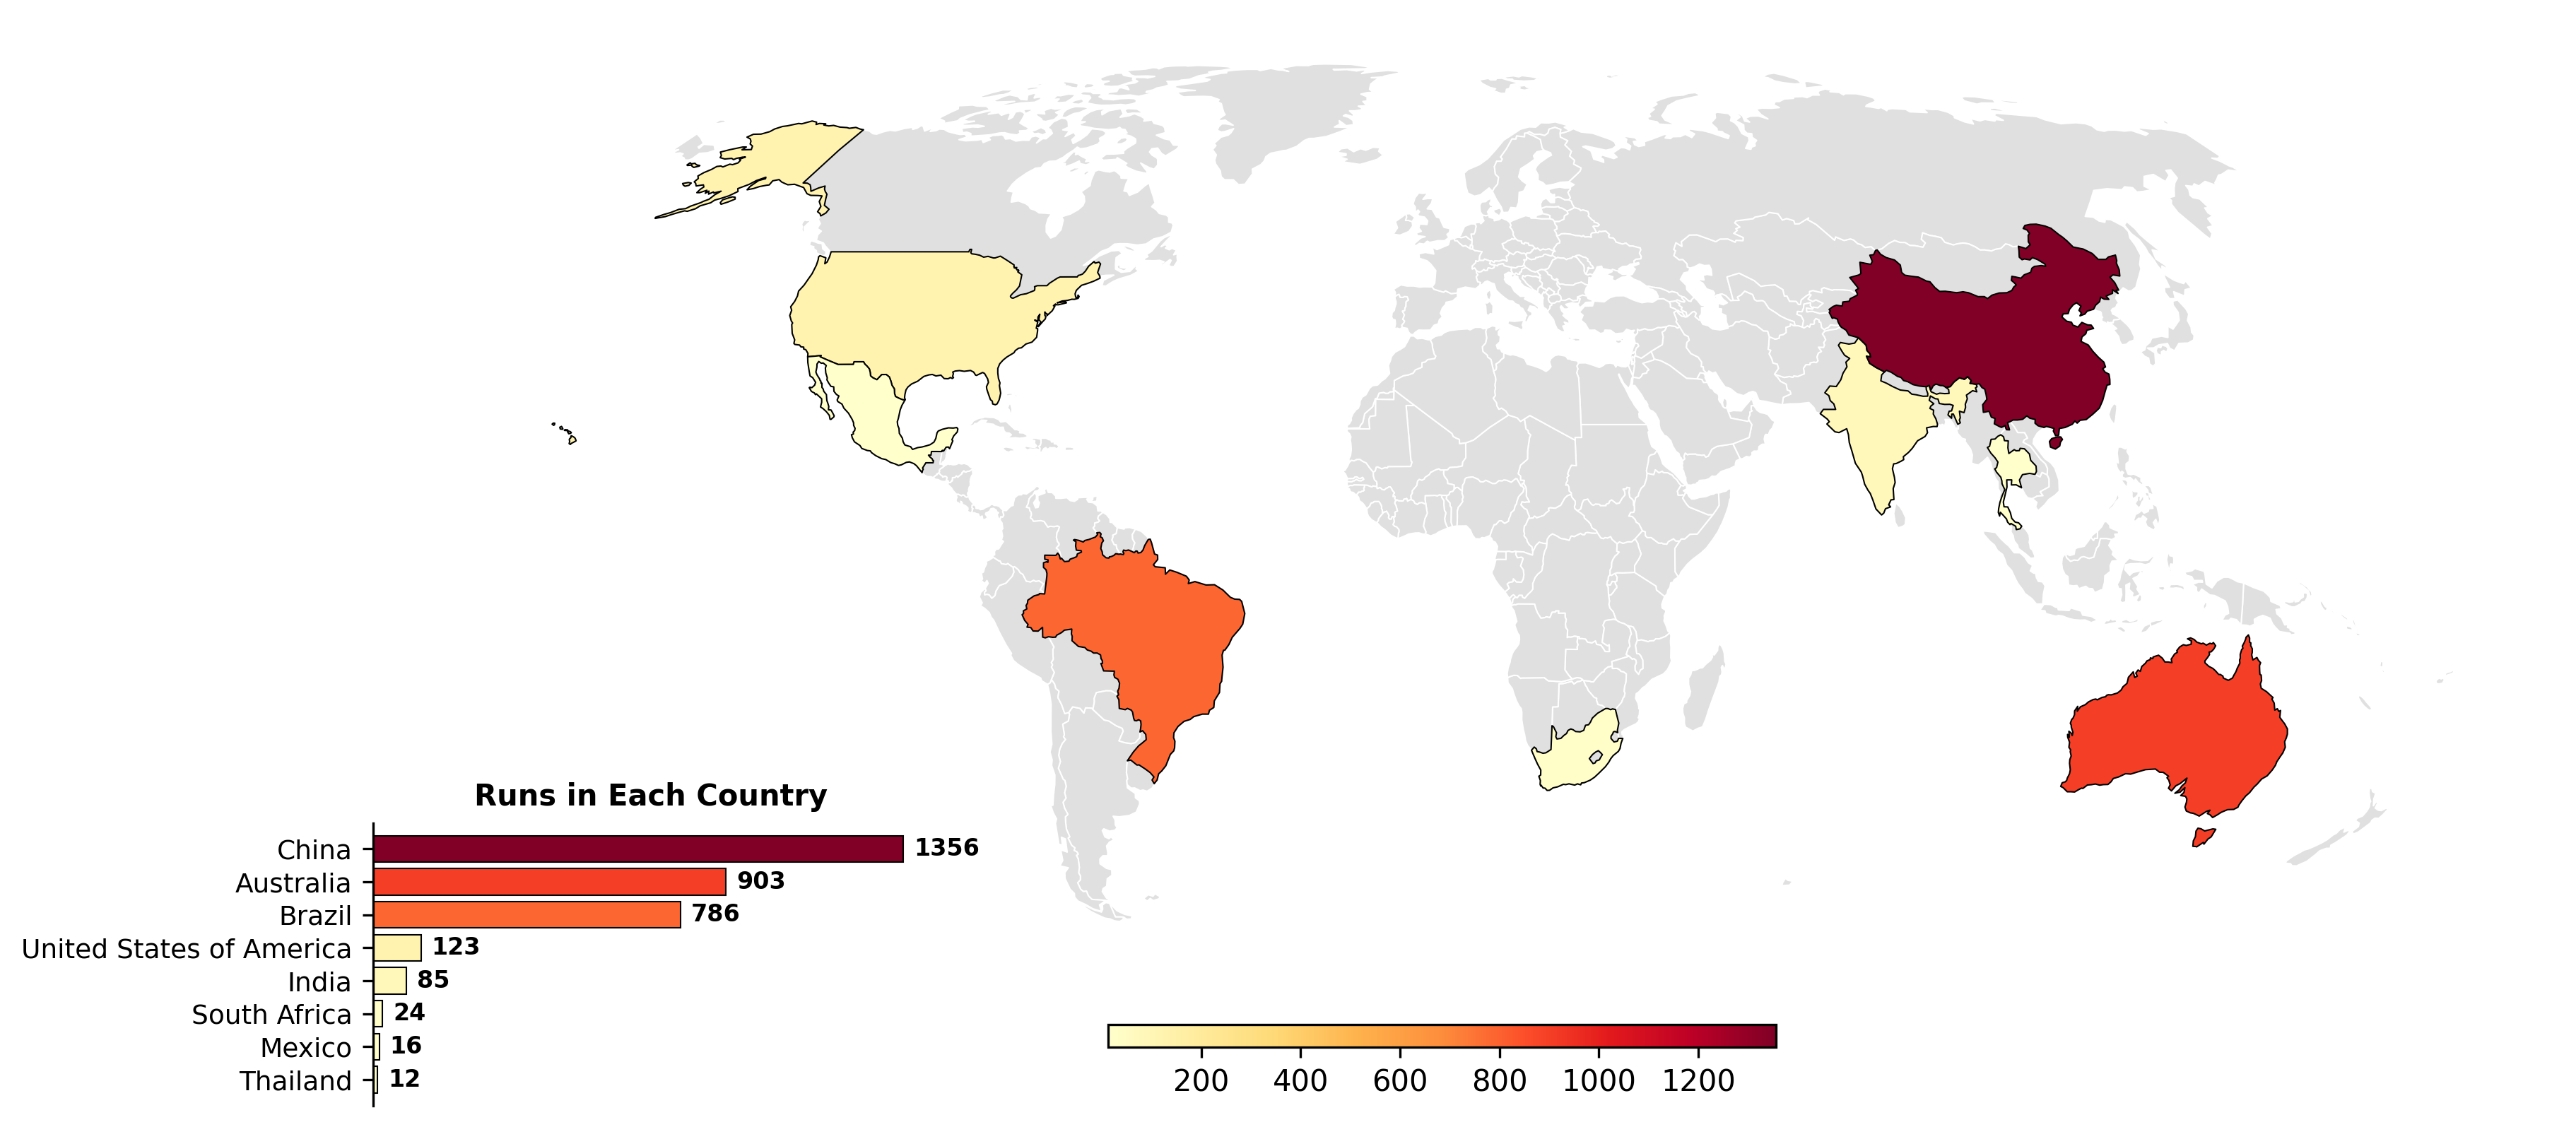

In [6]:
# Configure plot aesthetics for better readability in articles
fig, ax = plt.subplots(1, 1, figsize=(12, 6), dpi=300)

# Plot the base map with neutral colors for countries without data
world_data.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.5)

# Plot the countries with data using a color map that is friendly for colorblind readers
data_countries = world_data.dropna(subset=["count"])
data_countries.plot(
    column="count",
    ax=ax,
    cmap="YlOrRd",  # Or 'viridis' YlOrRd
    legend=True,
    edgecolor="black",  # Slightly darker border for countries with data
    linewidth=0.5,
    legend_kwds={
        # 'label': "Runs in Each Country",
        "orientation": "horizontal",
        "shrink": 0.3,  # Size of the legend bar
        "pad": 0.05,  # Distance between the map and the legend
        "aspect": 30,  # Aspect ratio of the legend bar
    },
)

# Remove axes (latitude and longitude) for a clean look
ax.axis("off")

# Inset axes
data_countries_sorted = data_countries.sort_values(by="count", ascending=True)

# Position and size of the inset bar plot (x, y, width, height)
ax_bar = ax.inset_axes([0.02, -0.15, 0.25, 0.30])

norm = mcolors.Normalize(
    vmin=data_countries["count"].min(), vmax=data_countries["count"].max()
)
cmap = plt.get_cmap("YlOrRd")
bar_colors = [cmap(norm(valor)) for valor in data_countries_sorted["count"]]

# Clean data
country_names = data_countries_sorted["NAME"].astype(str).tolist()
values = data_countries_sorted["count"].to_numpy()

# Using numpy create a range of positions for the bars
positions = np.arange(len(country_names))

# Bar plot
bars = ax_bar.barh(
    y=positions, width=values, color=bar_colors, edgecolor="black", linewidth=0.5
)

# Include the values at the end of each bar
for index, value in enumerate(values):
    ax_bar.text(
        value + (max(values) * 0.02),  # x position (a little to the right of the bar)
        index,  # y position (centered on the bar)
        str(int(value)),  # text to display
        va="center",  # vertical alignment centered
        fontsize=8,
        fontweight="bold",
    )

# Remove axes for the inset plot
ax_bar.set_xticks([])
ax_bar.spines["bottom"].set_visible(False)

# Change y-axis labels to country names
ax_bar.set_yticks(positions)
ax_bar.set_yticklabels(country_names)

# Clean formatting for the inset bar plot
ax_bar.set_title("Runs in Each Country", fontsize=10, fontweight="bold")
ax_bar.tick_params(axis="y", labelsize=9)
ax_bar.tick_params(axis="x", labelsize=8)

# Pretty formatting for the inset bar plot
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# Optional
# ax_bar.set_facecolor('#f8f9fa')
# ax_bar.patch.set_alpha(0.8)


# Title
# ax.set_title("Global Distribution of Occurrences", fontsize=14, pad=15)

# Adjust layout to avoid cutting off elements
plt.tight_layout()

# Save the figure in high resolution in TIFF or PDF formats
# plt.savefig("mapa_coropletico_alta_res.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../figures/map.png", bbox_inches="tight", dpi=300)

plt.show()

Text(39.120000000000005, 0, '12')

Text(43.120000000000005, 1, '16')

Text(51.120000000000005, 2, '24')

Text(112.12, 3, '85')

Text(150.12, 4, '123')

Text(813.12, 5, '786')

Text(930.12, 6, '903')

Text(1383.12, 7, '1356')

[Text(0, 0, 'Thailand'),
 Text(0, 1, 'Mexico'),
 Text(0, 2, 'South Africa'),
 Text(0, 3, 'India'),
 Text(0, 4, 'United States of America'),
 Text(0, 5, 'Brazil'),
 Text(0, 6, 'Australia'),
 Text(0, 7, 'China')]

Text(0.5, 1.0, 'Runs in Each Country')

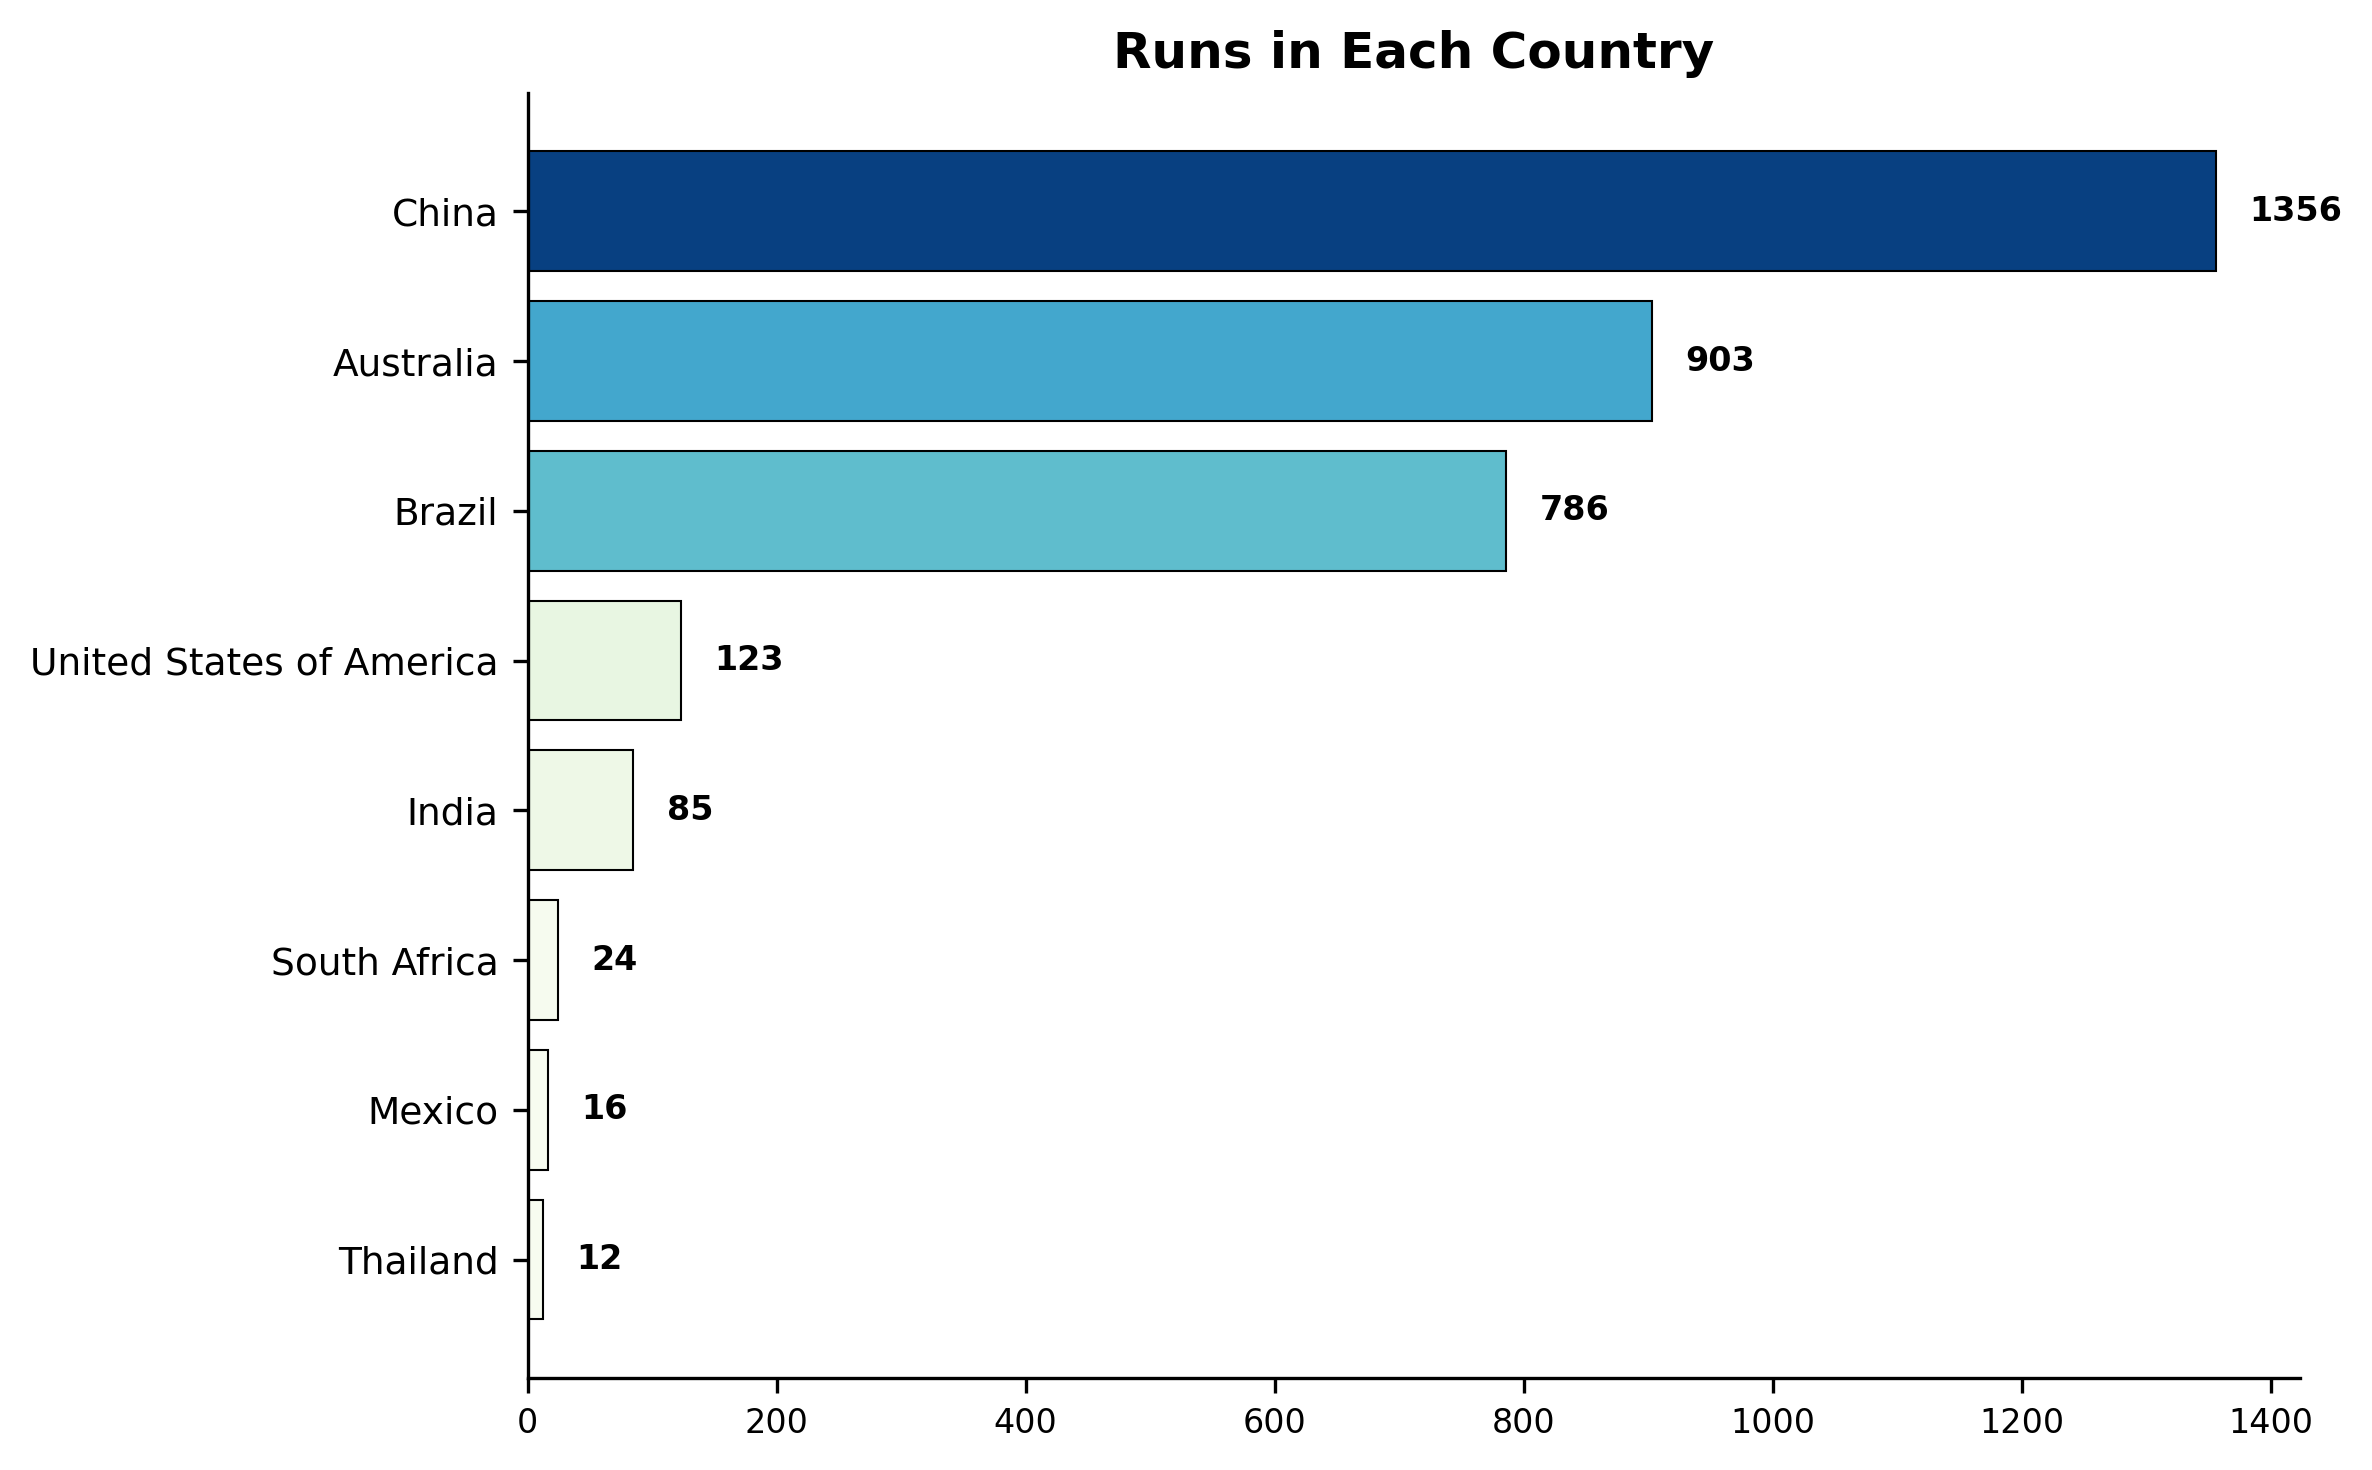

In [7]:
# Plot the countries with data using a color map that is friendly for colorblind readers
data_countries = world_data.dropna(subset=["count"])

# Sort the data by count for better visualization in the bar plot
data_countries_sorted = data_countries.sort_values(by="count", ascending=True)

# Color normalization for the bar plot
norm = mcolors.Normalize(
    vmin=data_countries["count"].min(),
    vmax=data_countries["count"].max()
)
cmap = plt.get_cmap("GnBu")
bar_colors = [cmap(norm(valor)) for valor in data_countries_sorted["count"]]

# Data for the bar plot
country_names = data_countries_sorted["NAME"].astype(str).tolist()
values = data_countries_sorted["count"].to_numpy()
positions = np.arange(len(country_names))

# Figure and axis for the bar plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Barplot horizontal
bars = ax.barh(
    y=positions,
    width=values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

# Values at the end of the bars
for index, value in enumerate(values):
    ax.text(
        value + (max(values) * 0.02),
        index,
        str(int(value)),
        va="center",
        fontsize=8,
        fontweight="bold",
    )

# Remove axes for the bar plot
ax.set_yticks(positions)
ax.set_yticklabels(country_names)
ax.set_title("Runs in Each Country", fontsize=12, fontweight="bold")

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=8)

# Aesthetic adjustments for the bar plot
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save the bar plot in high resolution in TIFF or PDF formats
plt.savefig("../figures/barplot.png", bbox_inches="tight", dpi=300)

plt.show()

# Growth condition

In [8]:
# Calculate counts and percentages
df_unique_gr = df.drop_duplicates(subset=["BioProject", "growth_conditions"]).copy()

# Calculate counts and percentages for growth conditions
gc_counts = df_unique_gr["growth_conditions"].value_counts()
total_samples = len(df_unique_gr)
percentages = (gc_counts / total_samples) * 100

Text(0.0, 60.18, 'N=59\n(37.3%)')

Text(1.0, 52.18, 'N=51\n(32.3%)')

Text(2.0, 2.1799999999999997, 'N=1\n(0.6%)')

Text(0, 0.5, 'Number of Occurrences')

Text(0.5, 0, 'Growth Conditions')

(0.0, 67.85)

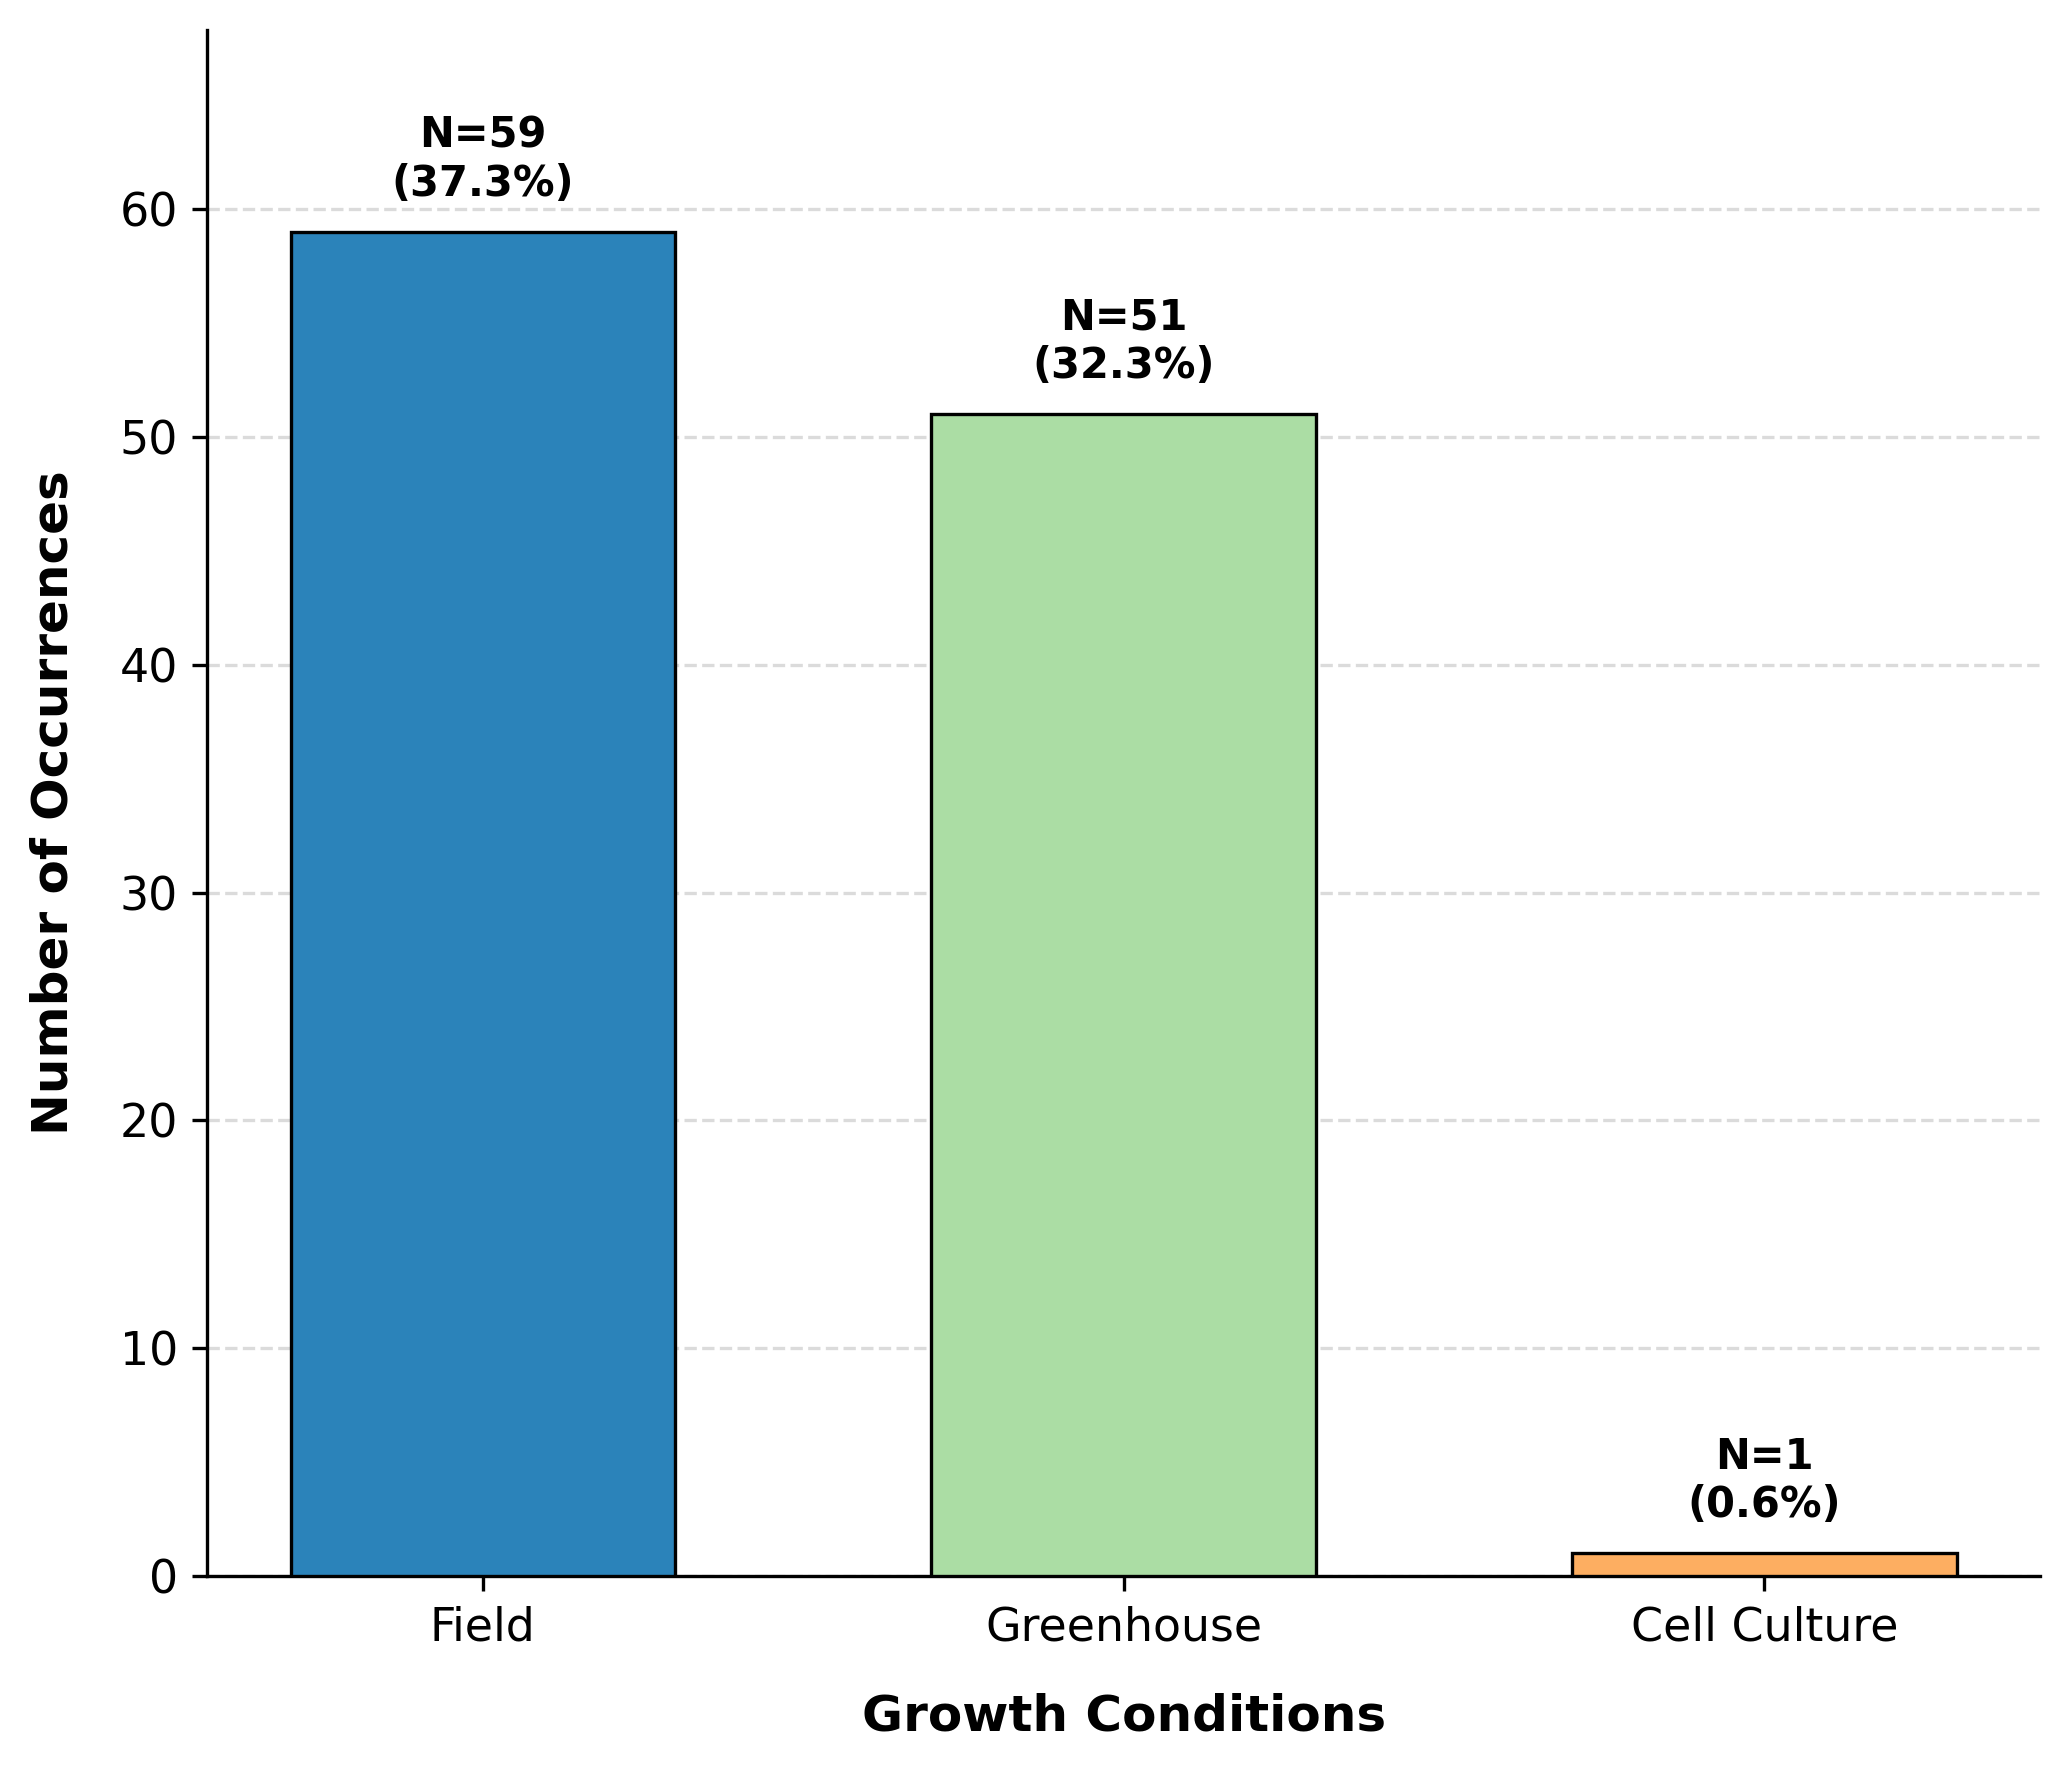

In [9]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Define a clean, colorblind-friendly color palette for the 3 categories
# Colors: Dark Blue, Light Blue, Orange/Gold
colors = ["#2b83ba", "#abdda4", "#fdae61"]

# Create the bar chart on the specified 'ax'
# 'zorder=3' ensures bars are drawn on top of the grid lines
bars = ax.bar(
    gc_counts.index,
    gc_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6,
    zorder=3,
)

# Add exact N and % on top of each bar
for bar, count, pct in zip(bars, gc_counts.values, percentages.values):
    height = bar.get_height()
    # Adding the text slightly above the bar (pad = 2% of the max height)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (gc_counts.max() * 0.02),
        f"N={count}\n({pct:.1f}%)",  # Format: N=value (xx.x%)
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Clean up the axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a subtle horizontal grid for better readability of the Y-axis values
ax.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax.set_axisbelow(True)  # Ensure grid is strictly behind the bars

# Set labels and title
ax.set_ylabel("Number of Occurrences", fontsize=12, fontweight="bold", labelpad=10)
ax.set_xlabel("Growth Conditions", fontsize=12, fontweight="bold", labelpad=10)

# Adjust tick label sizes
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Ensure Y-axis has enough headroom for the text annotations (expand top limit by 15%)
ax.set_ylim(0, gc_counts.max() * 1.15)

# Adjust layout
plt.tight_layout()

# Save the bar plot in high resolution in TIFF or PDF formats
plt.savefig("../figures/growth_conditions.png", bbox_inches="tight", dpi=300)

plt.show()

# RunCount

Text(0.5, 0, 'Number of Runs per BioProject (Log Scale)')

Text(0, 0.5, 'Frequency (Number of BioProjects)')

Text(0.95, 0.95, 'Total BioProjects: 158\nMedian Runs/Project: 10\nMean Runs/Project: 21.4')

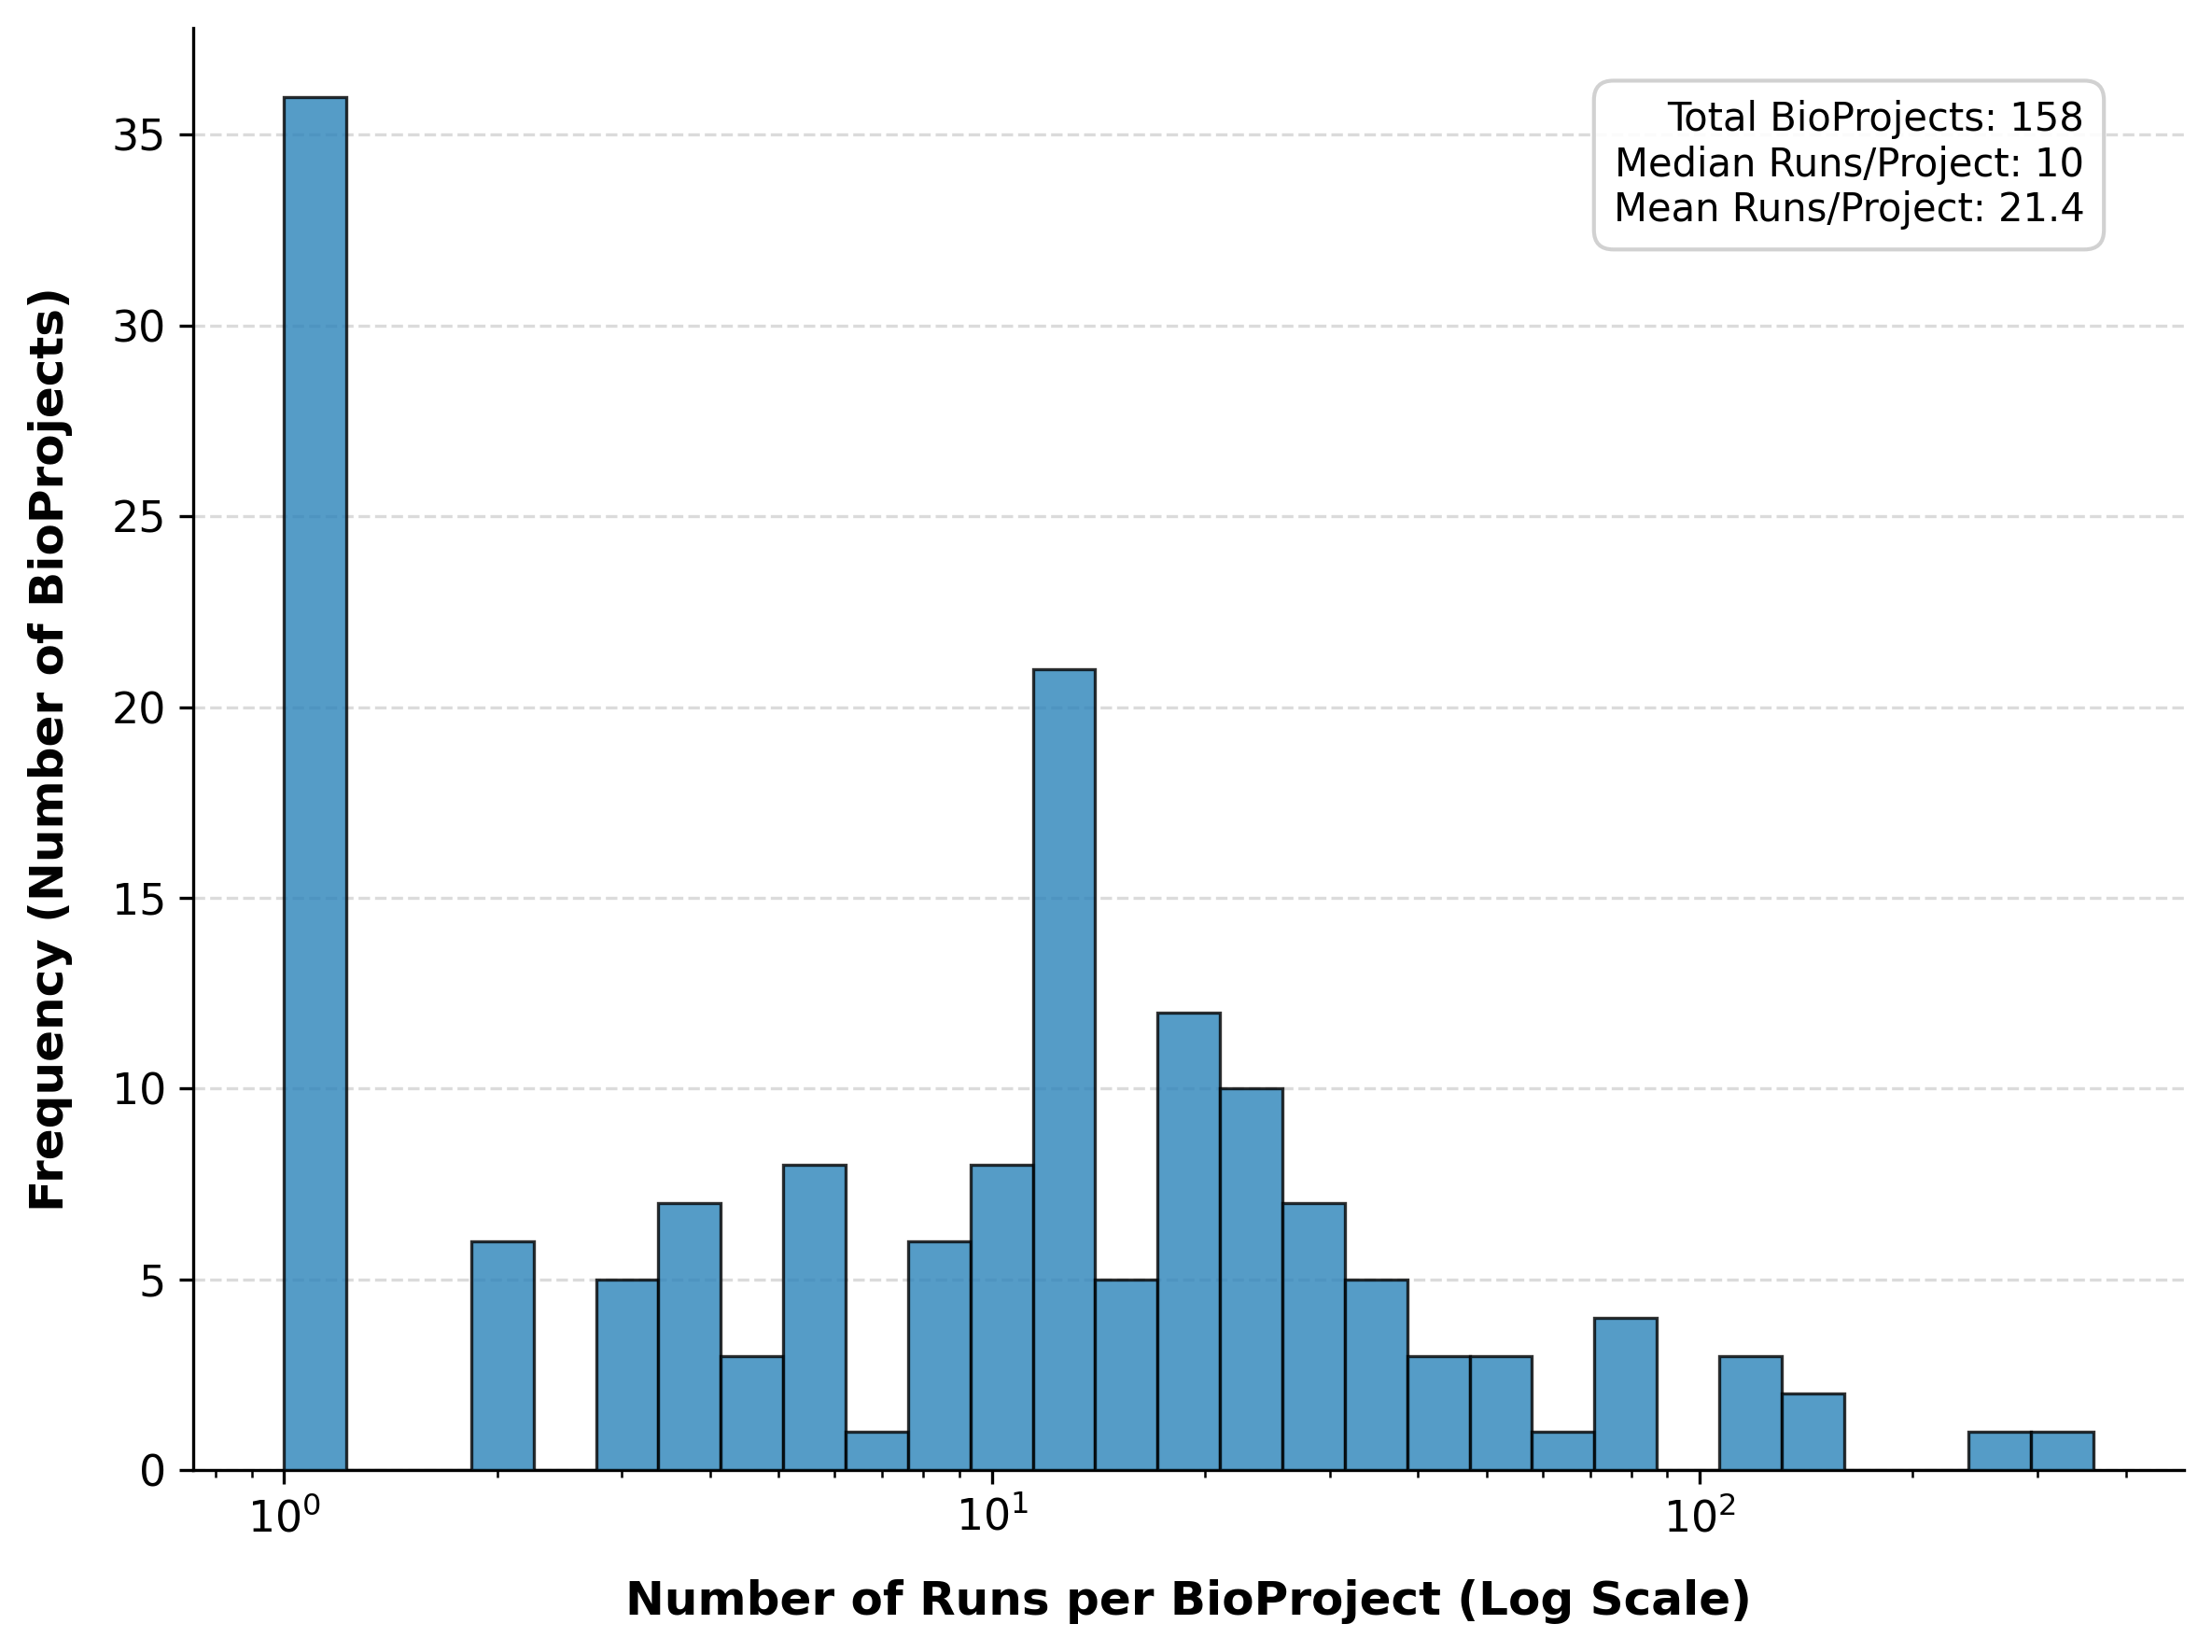

In [10]:
# Toggle for Logarithmic Scale
USE_LOG_SCALE = True
# Deduplicate the data
# We only want one row per BioProject to understand project size distribution
df_projects = df.drop_duplicates(subset=["BioProject"]).copy()
run_counts = df_projects["RunCount"]

# Subplot Setup & Plotting
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Conditional logic for Bins and Scale based on the toggle
if USE_LOG_SCALE:
    # Log scale configuration
    min_val = max(1, run_counts.min())  # Avoid log(0)
    max_val = run_counts.max()
    # Create bins that grow logarithmically
    dynamic_bins = np.logspace(
        np.log10(min_val), np.log10(max_val), num=30
    )  # Use logspace for logarithmic bins
    ax.set_xscale("log")
    x_label = "Number of Runs per BioProject (Log Scale)"
else:
    # Linear scale configuration
    # Create 30 evenly spaced bins from min to max
    dynamic_bins = np.linspace(run_counts.min(), run_counts.max(), num=30)
    # The X-axis defaults to linear
    x_label = "Number of Runs per BioProject (Linear Scale)"

# Create the histogram
counts, bins, patches = ax.hist(
    run_counts,
    bins=dynamic_bins,
    color="#2b83ba",  # colorblind-friendly blue
    edgecolor="black",  # Distinct borders
    linewidth=0.8,
    alpha=0.8,  # Slight transparency
    zorder=3,  # Keep bars above the grid
)

# Clean up spines (remove top and right borders)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a subtle grid for the Y-axis
ax.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax.set_axisbelow(True)  # Ensure grid is behind the bars

# Set dynamic labels based on the scale chosen
ax.set_xlabel(x_label, fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel(
    "Frequency (Number of BioProjects)", fontsize=12, fontweight="bold", labelpad=10
)

# Tick formatting
ax.tick_params(axis="both", which="major", labelsize=11)

# Add a text box with summary statistics
median_runs = run_counts.median()
mean_runs = run_counts.mean()
total_projects = len(run_counts)

stats_text = (
    f"Total BioProjects: {total_projects}\n"
    f"Median Runs/Project: {median_runs:.0f}\n"
    f"Mean Runs/Project: {mean_runs:.1f}"
)

# Place text box in the upper right corner
ax.text(
    0.95,
    0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", alpha=0.9, edgecolor="#cccccc"
    ),
)

plt.tight_layout()

# Save the bar plot in high resolution in TIFF or PDF formats
plt.savefig("../figures/run_counts.png", bbox_inches="tight", dpi=300)

plt.show()

# Tissue

In [11]:
# Count treatment values
treatment_counts = df["tissue_ontology"].value_counts()
treatment_counts

tissue_ontology
PO:0025034    1478
PO:0020142     802
PO:0009047     426
PO:0009005     277
PO:0000055      79
PO:0004709      70
PO:0009046      37
PO:0009013      32
PO:0020121      30
PO:0020040      24
PO:0020137      12
PO:0020141       9
PO:0025223       9
PO:0025178       8
PO:0009011       6
PO:0006109       2
Name: count, dtype: int64

In [12]:
# Create a mapping from PO IDs to human-readable names
# Used the Plant Ontology (PO) database to find the corresponding names for each PO ID
# https://bioportal.bioontology.org/ontologies/PO
po2name = {
    "PO:0025034": "Leaf",
    "PO:0020142": "Stem Internode",
    "PO:0009047": "Stem",
    "PO:0009005": "Root",
    "PO:0000055": "Bud",
    "PO:0004709": "Auxiliary Bud",
    "PO:0009046": "Flower",
    "PO:0009013": "Meristem",
    "PO:0020121": "Lateral Root",
    "PO:0020040": "Leaf Base",
    "PO:0020137": "Leaf Apex",
    "PO:0020141": "Stem Node",
    "PO:0025223": "Vegetative Shoot Apex",
    "PO:0025178": "Stem Epidermis",
    "PO:0009011": "Plant Structure",
    "PO:0006109": "Pith",
}

<Axes: >

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

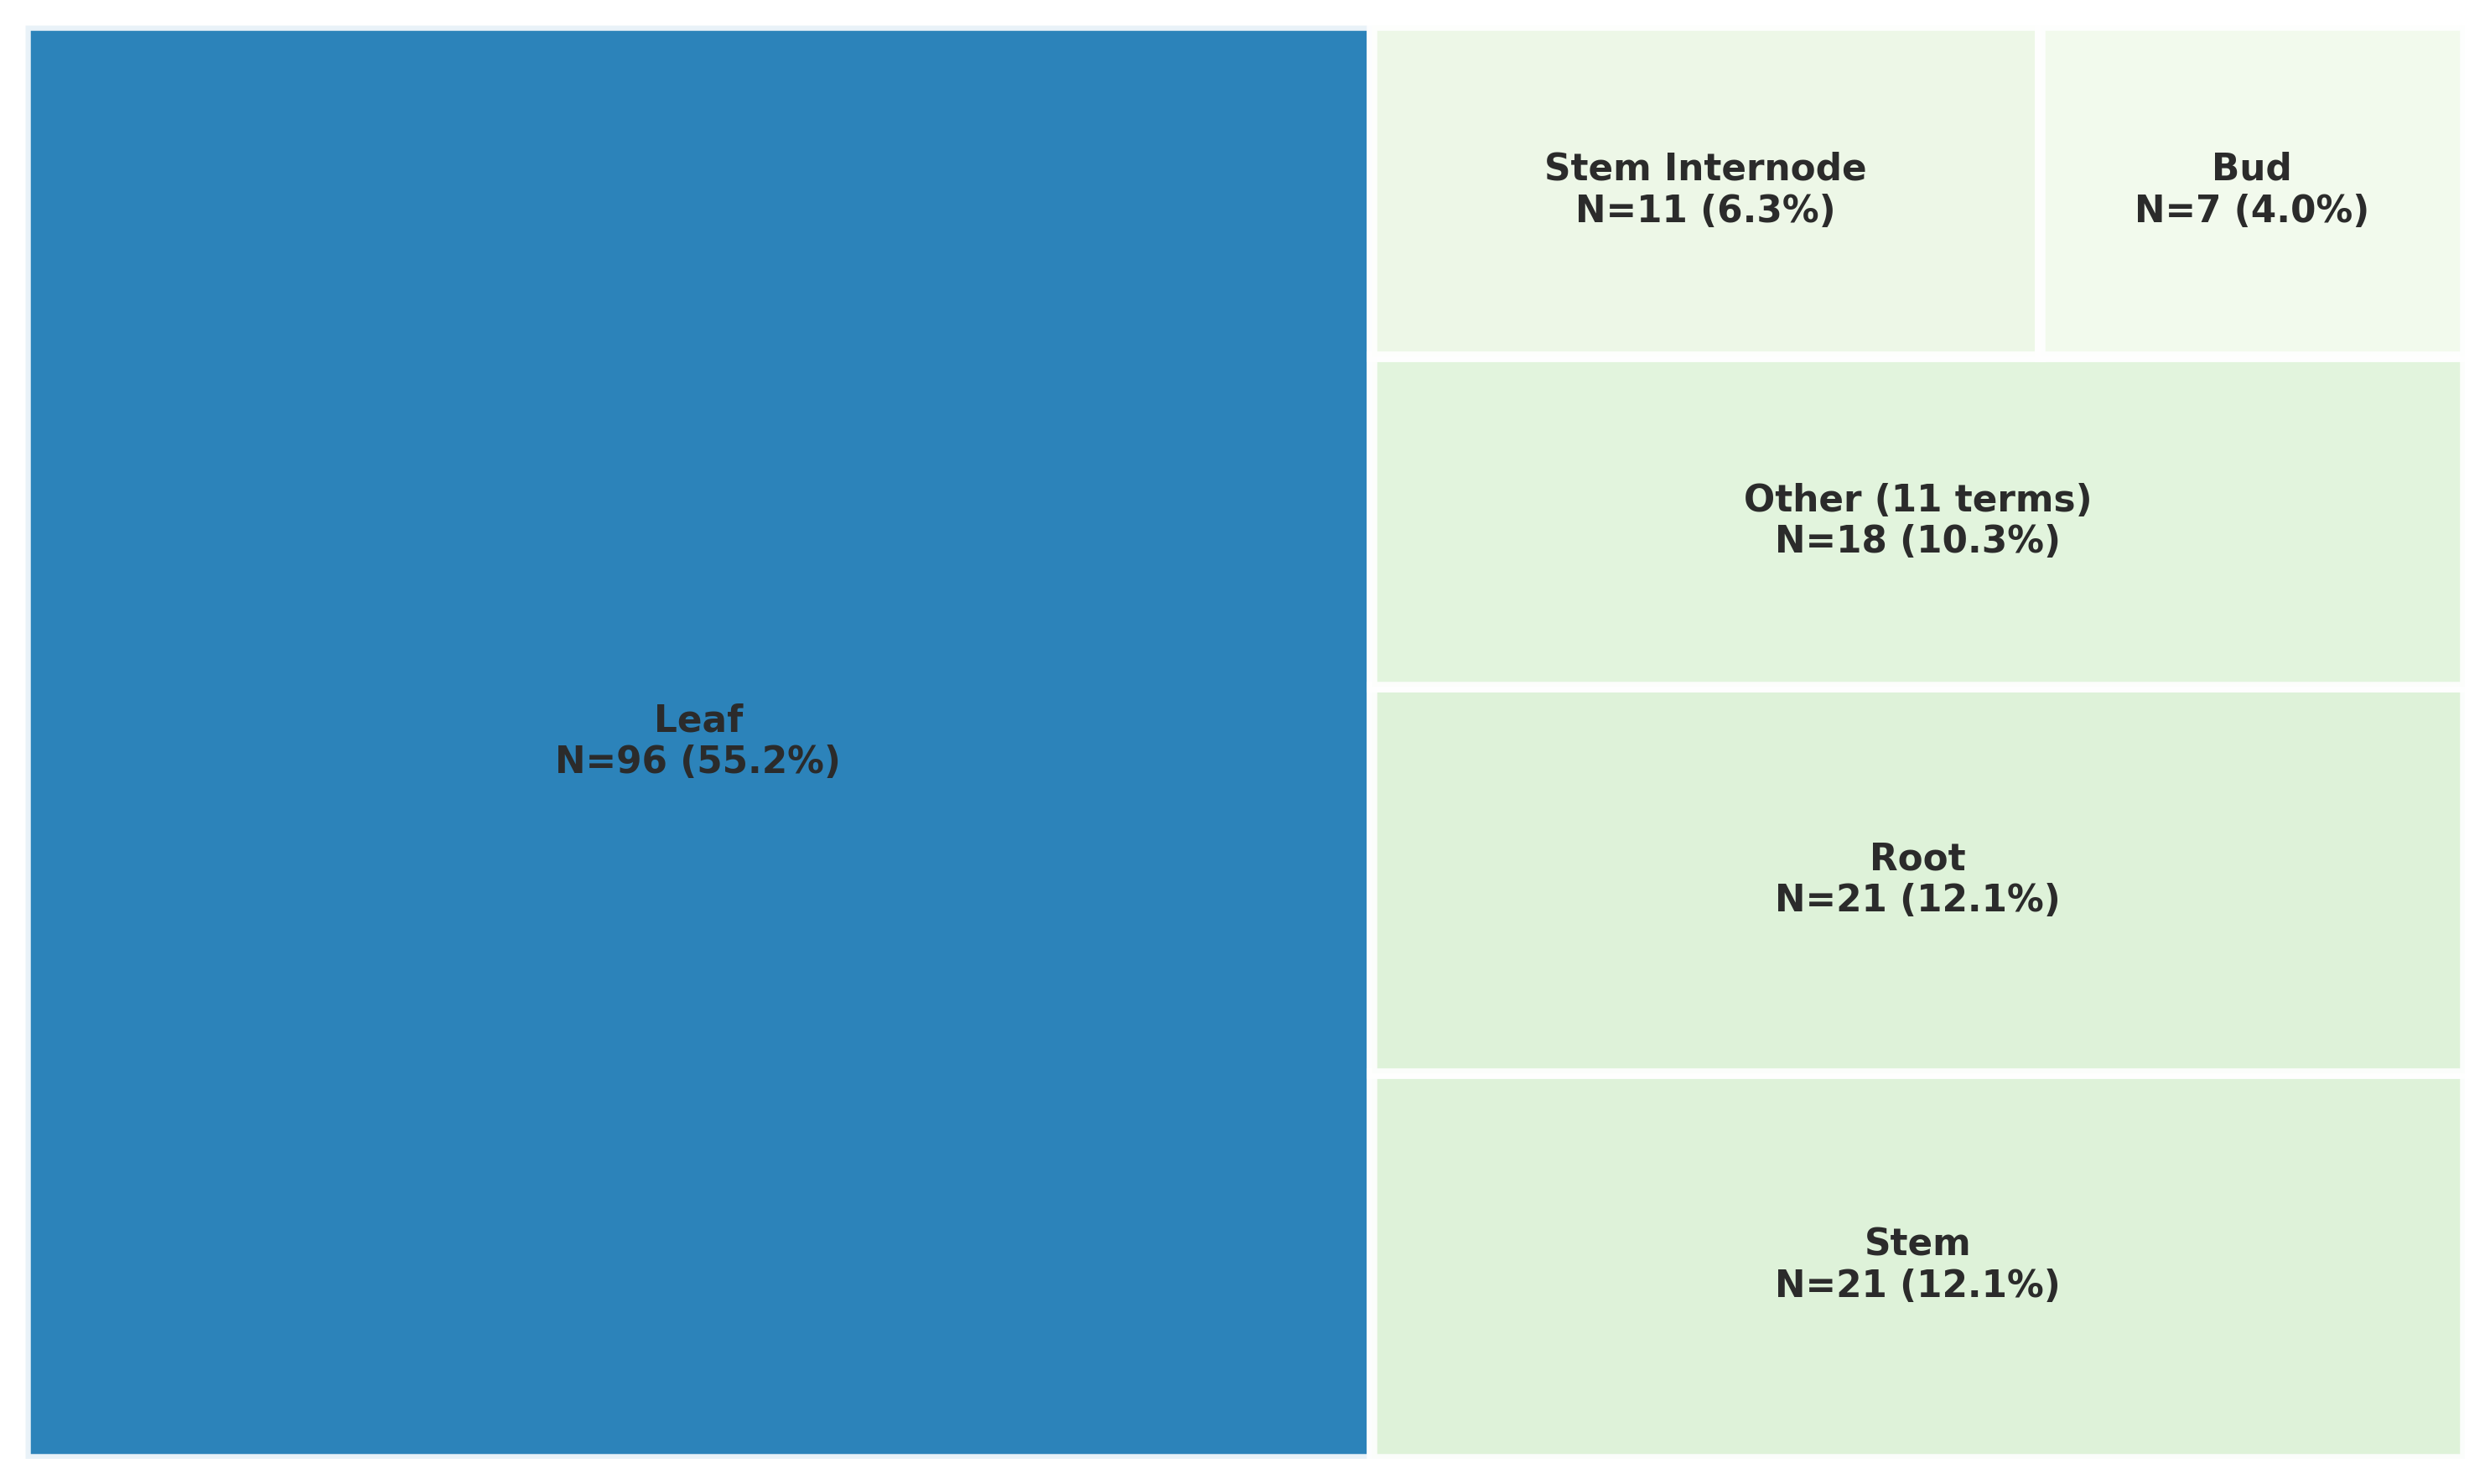

In [13]:
# Map the Plant Ontology IDs to human-readable names
df["ontology_term"] = df["tissue_ontology"].map(po2name)

# Deduplicate: Count each tissue only ONCE per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Green-Blue colormap colorblind-friendly
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context
labels = [
    f"{row['ontology_term']}\nN={row['count']} ({row['percentage']:.1f}%)"
    for _, row in term_counts_clean.iterrows()
]

# Plot the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax,
)

# Remove axes for a clean, minimalist look
ax.axis("off")

plt.tight_layout()

# Save the bar plot in high resolution in TIFF or PDF formats
plt.savefig("../figures/tissue_distribution.png", bbox_inches="tight", dpi=300)

plt.show()

# Treatment

In [14]:
# count treatment_ontology counts
treatment_counts = df["treatment_ontology"].str.strip().value_counts()
treatment_counts

treatment_ontology
PECO:0001062                 228
PECO:0007404                 197
PECO:0007241                 103
PECO:0007357                  76
PECO:0007189                  74
PECO:0007191                  52
PECO:0007174                  15
PECO:0007357,PECO:0007404     13
PECO:0007333                  12
PECO:0007050                  12
PECO:0007078                  12
PECO:0007189,PECO:0007165      9
PECO:0007189,PECO:0007404      5
PECO:0007185                   4
PECO:0001037                   2
PECO:0007173                   1
Name: count, dtype: int64

In [15]:
# Create a mapping from PECO IDs to human-readable names
# Used the Plant Experimental Conditions Ontology (PECO) database to find the corresponding names for each PECO ID
# https://bioportal.bioontology.org/ontologies/PECO
peco2name = {
    "PECO:0001062": "Control",
    " PECO:0001062": "Control",
    "PECO:0007404": "Drought",
    "PECO:0007241": "Plant Nutrient",
    "PECO:0007357": "Biotic Plant",
    "PECO:0007189": "Chemical",
    "PECO:0007191": "Abiotic Plant",
    "PECO:0007174": "Cold Temperature",
    "PECO:0007357,PECO:0007404": "Biotic + Drought",
    "PECO:0007333": "Insect Plant",
    "PECO:0007050": "Soil Texture",
    "PECO:0007078": "Light Quantity",
    "PECO:0007189,PECO:0007165": "Chemical + Plant Growth Hormone",
    "PECO:0007189,PECO:0007404": "Chemical + Drought",
    "PECO:0007185": "Salt",
    "PECO:0001037": "Oxidative Stress",
    "PECO:0007173": "High Temperature",
}

<Axes: >

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

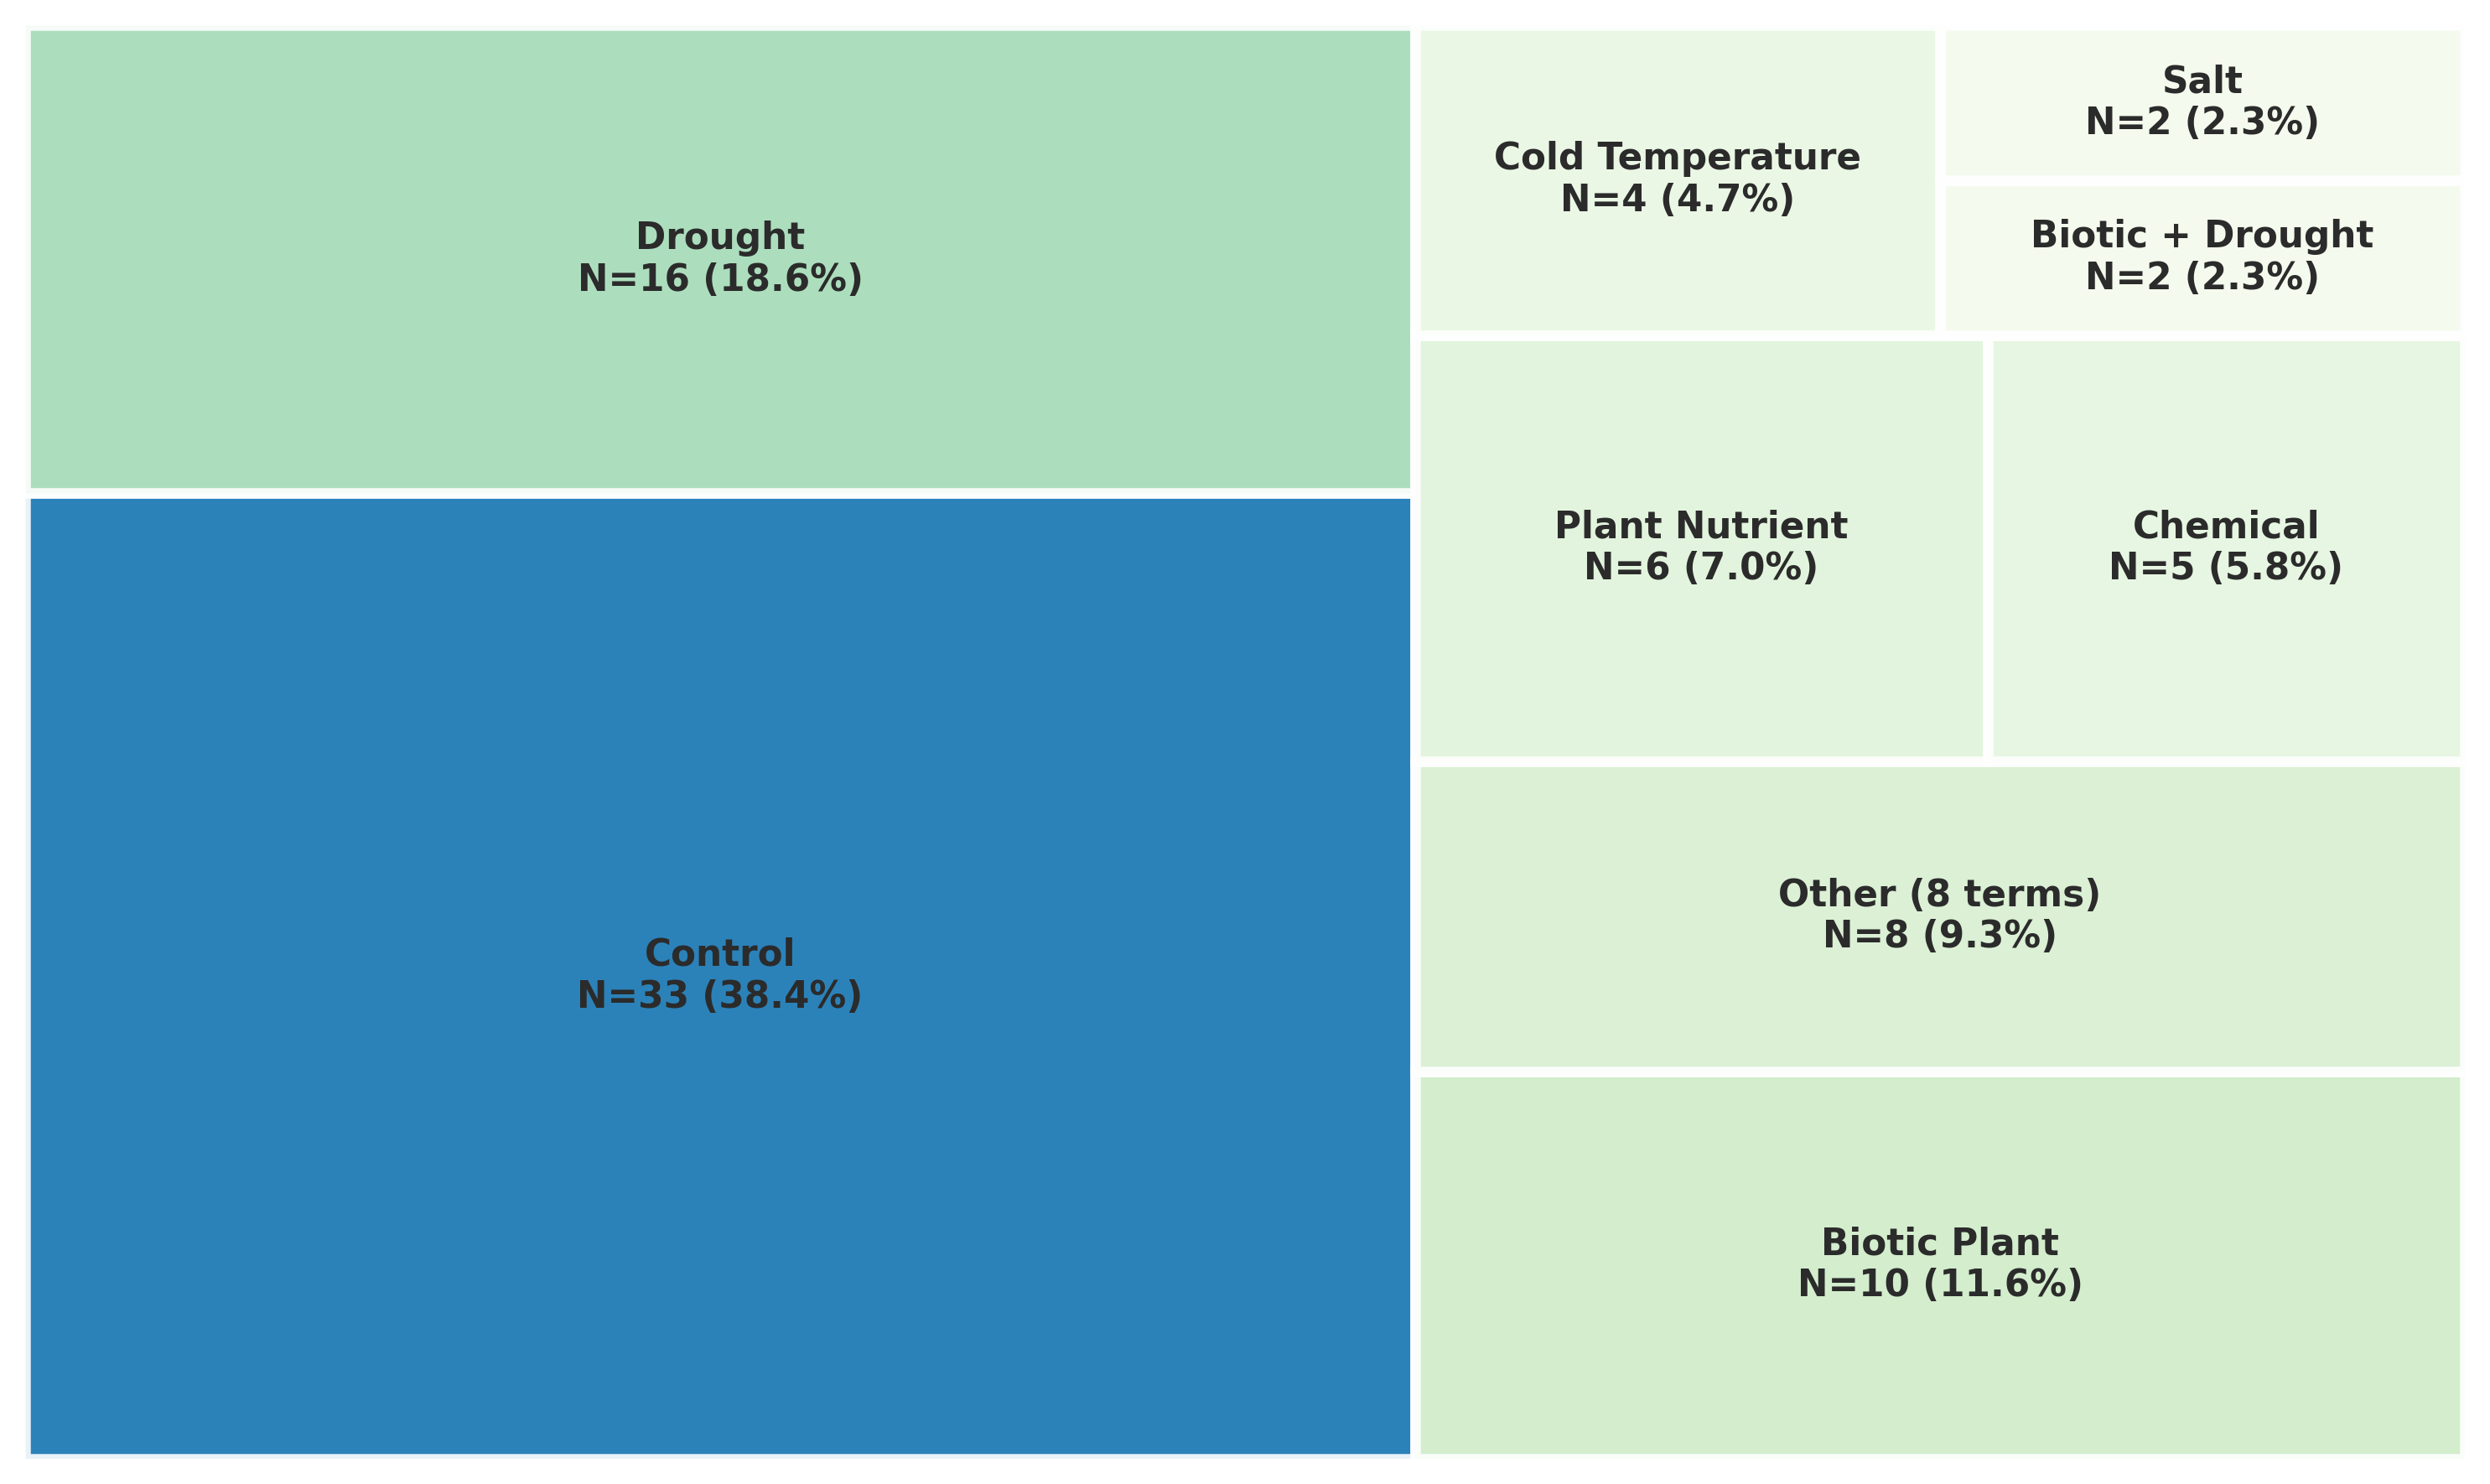

In [16]:
# Map the Plant Ontology IDs to human-readable names
df["ontology_term_treat"] = df["treatment_ontology"].map(peco2name)

# Deduplicate: Count each tissue only once per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term_treat"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term_treat"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Green-Blue colormap colorblind-friendly
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context
labels = [
    f"{row['ontology_term']}\nN={row['count']} ({row['percentage']:.1f}%)"
    for _, row in term_counts_clean.iterrows()
]

# Plot the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax,
)

# Remove axes for a clean, minimalist look
ax.axis("off")

plt.tight_layout()

# Save the bar plot in high resolution in TIFF or PDF formats
plt.savefig("../figures/treatment_distribution.png", bbox_inches="tight", dpi=300)

plt.show()

# Create Panel

Text(0.0, 60.18, 'N=59\n(37.3%)')

Text(1.0, 52.18, 'N=51\n(32.3%)')

Text(2.0, 2.1799999999999997, 'N=1\n(0.6%)')

Text(0, 0.5, 'Number of Occurrences')

Text(0.5, 0, 'Growth Conditions')

...

[Text(0, 0, 'Thailand'),
 Text(0, 1, 'Mexico'),
 Text(0, 2, 'South Africa'),
 Text(0, 3, 'India'),
 Text(0, 4, 'United States of America'),
 Text(0, 5, 'Brazil'),
 Text(0, 6, 'Australia'),
 Text(0, 7, 'China')]

Text(0.5, 1.0, 'Runs in Each Country')

(np.float64(0.0),
 np.float64(1423.8),
 np.float64(-0.79),
 np.float64(7.789999999999999))

Text(-0.1, 1.05, 'C')

/tmp/ipykernel_18705/3255073175.py:411: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


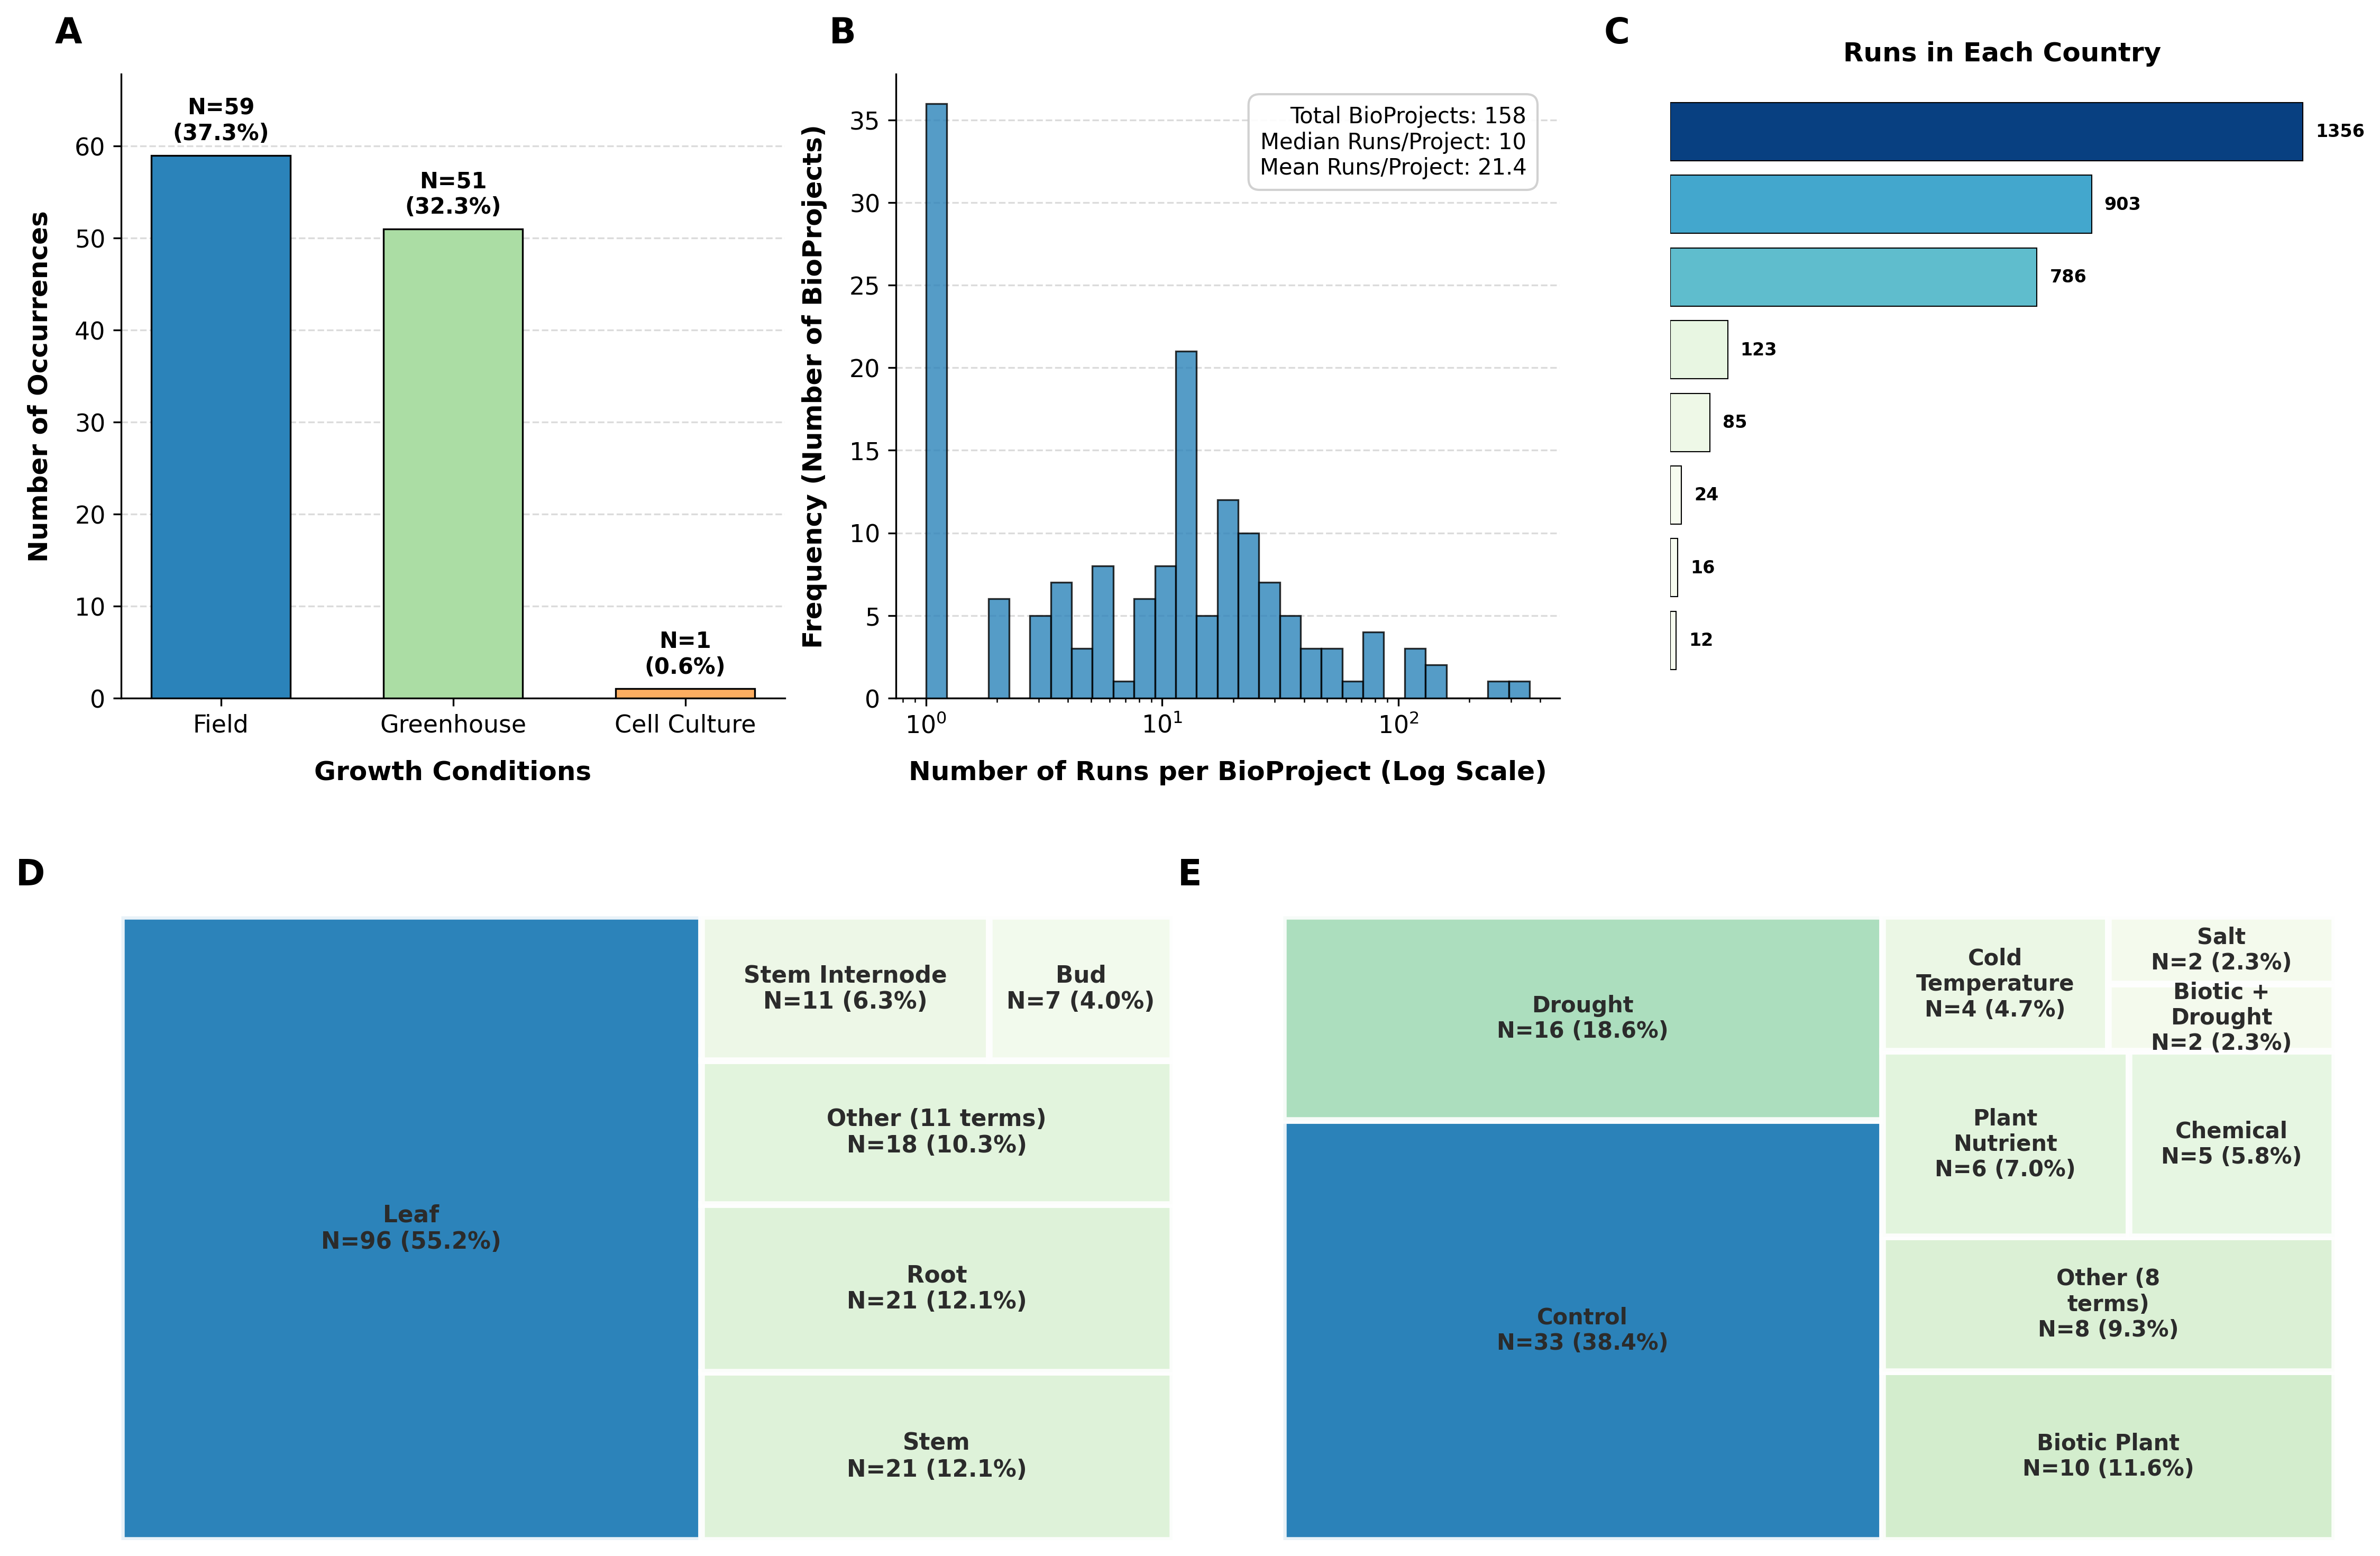

In [17]:
# Put all graphics together
# All graphics are already created in separate cells, so we just need to create a new figure and axes to place them together.
# fig, axes = plt.subplots(2, 3, figsize=(16, 12), dpi=300)
# Create figure with GridSpec for asymmetric layout
fig = plt.figure(figsize=(18, 12), dpi=300)

# Use GridSpec: 2 rows, 6 columns
# Top row: 3 panels of equal width (each spans 2 of 6 columns)
# Bottom row: 2 panels centered (each spans 2 of 6 columns, with 1 col padding on each side)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.4)

ax_a = fig.add_subplot(gs[0, 0:2])  # Top-left
ax_b = fig.add_subplot(gs[0, 2:4])  # Top-center
ax_e = fig.add_subplot(gs[0, 4:6])  # Top-right

ax_c = fig.add_subplot(gs[1, 0:3])  # Panel C - Tissue TreeMap (bottom-left)
ax_d = fig.add_subplot(gs[1, 3:6])  # Panel D - Treatment TreeMap (bottom-right)

########################################################################################
# Changed the order of the panels to match the typical reading flow (left-to-right, top-to-bottom) and to place the most complex plot (the TreeMap)
# in the bottom-left where it can be easily compared with the simpler bar chart of growth conditions in the top-right.
# Growth Conditions (top-right)
# ax_a = axes[0, 1]


# Define a clean, colorblind-friendly color palette for the 3 categories
# Colors: Dark Blue, Light Blue, Orange/Gold
colors = ["#2b83ba", "#abdda4", "#fdae61"]

# Create the bar chart on the specified 'ax_a'
# 'zorder=3' ensures bars are drawn on top of the grid lines
bars = ax_a.bar(
    gc_counts.index,
    gc_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6,
    zorder=3,
)

# Add exact N and % on top of each bar
for bar, count, pct in zip(bars, gc_counts.values, percentages.values):
    height = bar.get_height()
    # Adding the text slightly above the bar (pad = 2% of the max height)
    ax_a.text(
        bar.get_x() + bar.get_width() / 2,
        height + (gc_counts.max() * 0.02),
        f"N={count}\n({pct:.1f}%)",  # Format: N=value (xx.x%)
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Clean up the axes
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)

# Add a subtle horizontal grid for better readability of the Y-axis values
ax_a.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax_a.set_axisbelow(True)  # Ensure grid is strictly behind the bars

# Set labels and title
# but Y-axis labels are mandatory.
ax_a.set_ylabel("Number of Occurrences", fontsize=12, fontweight="bold", labelpad=10)
ax_a.set_xlabel("Growth Conditions", fontsize=12, fontweight="bold", labelpad=10)

# Adjust tick label sizes
ax_a.tick_params(axis="x", labelsize=11)
ax_a.tick_params(axis="y", labelsize=11)

# Ensure Y-axis has enough headroom for the text annotations (expand top limit by 15%)
ax_a.set_ylim(0, gc_counts.max() * 1.15)

# Panel A Label
ax_a.annotate(
    "A", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Runs Histogram (top-left)
# ax_b = axes[0, 0]

USE_LOG_SCALE = True

# We only want one row per BioProject to understand project size distribution
df_projects = df.drop_duplicates(subset=["BioProject"]).copy()
run_counts = df_projects["RunCount"]

# Conditional logic for Bins and Scale based on the toggle
if USE_LOG_SCALE:
    # Log scale configuration
    min_val = max(1, run_counts.min())  # Avoid log(0)
    max_val = run_counts.max()
    # Create bins that grow logarithmically
    dynamic_bins = np.logspace(np.log10(min_val), np.log10(max_val), num=30)
    ax_b.set_xscale("log")
    x_label = "Number of Runs per BioProject (Log Scale)"
else:
    # Linear scale configuration
    # Create 30 evenly spaced bins from min to max
    dynamic_bins = np.linspace(run_counts.min(), run_counts.max(), num=30)
    # The X-axis defaults to linear
    x_label = "Number of Runs per BioProject (Linear Scale)"

# Create the histogram
counts, bins, patches = ax_b.hist(
    run_counts,
    bins=dynamic_bins,
    color="#2b83ba",  # Professional, colorblind-friendly blue
    edgecolor="black",  # Distinct borders
    linewidth=0.8,
    alpha=0.8,  # Slight transparency
    zorder=3,  # Keep bars above the grid
)

# Clean up spines (remove top and right borders)
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

# Add a subtle grid for the Y-axis
ax_b.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax_b.set_axisbelow(True)  # Ensure grid is behind the bars

# Set dynamic labels based on the scale chosen
ax_b.set_xlabel(x_label, fontsize=12, fontweight="bold", labelpad=10)
ax_b.set_ylabel(
    "Frequency (Number of BioProjects)", fontsize=12, fontweight="bold", labelpad=10
)

# Tick formatting
ax_b.tick_params(axis="both", which="major", labelsize=11)

# Add a text box with summary statistics
median_runs = run_counts.median()
mean_runs = run_counts.mean()
total_projects = len(run_counts)

stats_text = (
    f"Total BioProjects: {total_projects}\n"
    f"Median Runs/Project: {median_runs:.0f}\n"
    f"Mean Runs/Project: {mean_runs:.1f}"
)

# Place text box in the upper right corner
ax_b.text(
    0.95,
    0.95,
    stats_text,
    transform=ax_b.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", alpha=0.9, edgecolor="#cccccc"
    ),
)

# Panel B Label
ax_b.annotate(
    "B", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Tissue Ontology TreeMap (bottom-left)
# ax_c = axes[1, 0]

# Map the Plant Ontology IDs to human-readable names
df["ontology_term"] = df["tissue_ontology"].map(po2name)

# Deduplicate: Count each tissue only ONCE per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Use a softer, professional colormap (Green-Blue).
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context
labels = [
    f"{row['ontology_term']}\nN={row['count']} ({row['percentage']:.1f}%)"
    for _, row in term_counts_clean.iterrows()
]

# Plot the TreeMap
plt.sca(ax_c)   # Set the current axis to ax_c for the squarify plot
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax_c,
)

# Remove axes for a clean, minimalist look
ax_c.axis("off")
ax_c.annotate(
    "D", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Treatment Ontology TreeMap (bottom-right)
# ax_d = axes[1, 1]

# Map the Plant Ontology IDs to human-readable names
df["ontology_term_treat"] = df["treatment_ontology"].map(peco2name)

# Deduplicate: Count each tissue only ONCE per BioProject
df_unique = df.drop_duplicates(subset=["BioProject", "ontology_term_treat"]).copy()

# Calculate frequencies
term_counts = df_unique["ontology_term_treat"].value_counts().reset_index()
term_counts.columns = ["ontology_term", "count"]

# Grouping minor categories into "Other" if they are below a certain percentage threshold
# Avoid tailoring the plot to a long tail of very small categories that would be hard to read and interpret in a TreeMap
total_count = term_counts["count"].sum()
THRESHOLD_PERCENT = 2.0

# Calculate percentages for all terms to enrich our labels later
term_counts["percentage"] = (term_counts["count"] / total_count) * 100

# Separate major categories and minor categories based on the threshold
major_terms = term_counts[term_counts["percentage"] >= THRESHOLD_PERCENT].copy()
minor_terms = term_counts[term_counts["percentage"] < THRESHOLD_PERCENT].copy()

# If there are minor categories, aggregate them into an "Other" category
if not minor_terms.empty:
    other_count = minor_terms["count"].sum()
    other_percentage = minor_terms["percentage"].sum()
    num_minor_categories = len(minor_terms)

    # Create the aggregated row
    other_row = pd.DataFrame(
        {
            "ontology_term": [f"Other ({num_minor_categories} terms)"],
            "count": [other_count],
            "percentage": [other_percentage],
        }
    )

    # Combine major terms with the new aggregated row
    term_counts_clean = pd.concat([major_terms, other_row], ignore_index=True)
else:
    term_counts_clean = major_terms

# Sort so the largest boxes are positioned first (usually top-left)
term_counts_clean = term_counts_clean.sort_values(by="count", ascending=False)

# Green-Blue colormap colorblind-friendly
cmap = plt.colormaps.get_cmap("GnBu")

# Constrain the normalization range so the darkest color isn't purely dark.
# This ensures our dark gray text remains highly readable on all boxes.
norm = mcolors.Normalize(
    vmin=term_counts_clean["count"].min() * 0.5,
    vmax=term_counts_clean["count"].max() * 1.2,
)
color_list = [cmap(norm(value)) for value in term_counts_clean["count"]]

# Add percentage to the labels for immediate context and format the text to fit within the boxes
labels = []
for _, row in term_counts_clean.iterrows():
    # textwrap.fill will automatically insert line breaks to ensure the text fits within the specified width.
    split_name = textwrap.fill(str(row["ontology_term"]), width=12)

    # Combine the split name with the count and percentage, ensuring the entire label is concise and fits well within the box.
    final_name = f"{split_name}\nN={row['count']} ({row['percentage']:.1f}%)"
    labels.append(final_name)

# Plot the TreeMap
plt.sca(ax_d)  # Set the current axis to ax_d for the TreeMap
squarify.plot(
    sizes=term_counts_clean["count"],
    label=labels,
    color=color_list,
    alpha=0.9,  # Slightly less transparent for richer, solid colors
    edgecolor="white",  # Crisp white borders separate the blocks clearly
    linewidth=3,  # Thicker lines create a modern tile effect
    text_kwargs={
        "fontsize": 10,
        "fontweight": "bold",
        "color": "#2b2b2b",  # Soft dark gray is more elegant and easier to read than pure black
        "wrap": True,
    },
    ax=ax_d,
)

# Remove axes for a clean, minimalist look
ax_d.axis("off")

ax_d.annotate(
    "E", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

########################################################################################
# Barplot 
# ax_e = axes[0, 2]
# Plot the countries with data using a color map that is friendly for colorblind readers
data_countries = world_data.dropna(subset=["count"])

# Sort the data by count for better visualization in the bar plot
data_countries_sorted = data_countries.sort_values(by="count", ascending=True)

# Color normalization for the bar plot
norm = mcolors.Normalize(
    vmin=data_countries["count"].min(),
    vmax=data_countries["count"].max()
)
cmap = plt.get_cmap("GnBu")
bar_colors = [cmap(norm(valor)) for valor in data_countries_sorted["count"]]

# Data for the bar plot
country_names = data_countries_sorted["NAME"].astype(str).tolist()
values = data_countries_sorted["count"].to_numpy()
positions = np.arange(len(country_names))


# Barplot horizontal
bars = ax_e.barh(
    y=positions,
    width=values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

# Values at the end of the bars
for index, value in enumerate(values):
    ax_e.text(
        value + (max(values) * 0.02),
        index,
        str(int(value)),
        va="center",
        fontsize=8,
        fontweight="bold",
    )

# Remove axes for the bar plot
ax_e.set_yticks(positions)
ax_e.set_yticklabels(country_names)
ax_e.set_title("Runs in Each Country", fontsize=12, fontweight="bold")

ax_e.tick_params(axis="y", labelsize=9)
ax_e.tick_params(axis="x", labelsize=8)

# Aesthetic adjustments for the bar plot
ax_e.spines["top"].set_visible(False)
ax_e.spines["right"].set_visible(False)

ax_e.axis("off")
ax_e.annotate(
    "C", xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=16, fontweight="bold"
)

plt.tight_layout()

plt.savefig("../figures/figure_panel.png", bbox_inches="tight", dpi=300)

# Completeness

In [18]:
# Read the initial metadata dataset
sugarcane_rna_df = pd.read_csv('../raw/SraRunTable.csv', low_memory=False)

# Merge columns to create new coluns, reduce the sparsity of the data and make it more interpretable
# Select the columns
columns = [
    "Run",
    "Assay Type",
    "AvgSpotLen",
    "Bases",
    "BioProject",
    "BioSample",
    "Library Name",
    "Bytes",
    "Center Name",
    "Consent",
    "DATASTORE filetype",
    "DATASTORE provider",
    "DATASTORE region",
    "Experiment",
    "Instrument",
    "LibraryLayout",
    "LibrarySelection",
    "LibrarySource",
    "Organism",
    "Platform",
    "ReleaseDate",
    "Sample Name",
    "SRA Study",
    "create_date",
    "version",
    "BioSampleModel",
    "Collection_Date",
]

new_columns = [
    "geo_location",
    "growth_conditions",
    "sample_conditions",
    "genotype",
    "replicate",
]
# Create a dataframe with only relevant columns
sugar_rna_df_before = sugarcane_rna_df[columns]

# Replicate-related columns that may contain information about replicates, which we will combine into a single 'replicate' column.
cols_repl = [
    "replicates",
    "Biological_Replicate",
    "number_of_replicons",
    "replicate",
]

# Create the 'replicate' column by combining the relevant columns, handling missing values and ensuring proper formatting
# Splits the values in the specified columns, removes missing/invalid entries, and concatenates the valid parts with '| ' as a separator.
sugar_rna_df_before = sugar_rna_df_before.copy()

# This code creates a new 'replicate' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugar_rna_df_before.loc[:, "replicate"] = (
    sugarcane_rna_df[cols_repl]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'replicate' column
sugar_rna_df_before.loc[:, "replicate"] = sugar_rna_df_before[
    "replicate"
].replace("", pd.NA)

# Geographic location-related columns that may contain information about the geographic location of the samples, which we will combine into a single 'geo_location' column.
cols_geo = [
    "lat_lon",
    "geographic_location_(latitude)",
    "geographic_location_(longitude)",
    "geo_loc_name",
    "geo_loc_name_country",
    "geo_loc_name_country_continent",
]

# Create the 'geo_location' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'geo_location' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugar_rna_df_before = sugar_rna_df_before.copy()

sugar_rna_df_before.loc[:, "geo_location"] = (
    sugarcane_rna_df[cols_geo]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'geo_location' column
sugar_rna_df_before.loc[:, "geo_location"] = sugar_rna_df_before[
    "geo_location"
].replace("", pd.NA)

# Growth condition-related columns that may contain information about the growth conditions of the samples, which we will combine into a single 'growth_conditions' column.
cols_cndt = ["isolation_and_growth_condition", "plant_growth_medium", "growth_protocol"]

# Create the 'growth_conditions' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'growth_conditions' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugar_rna_df_before = sugar_rna_df_before.copy()

sugar_rna_df_before.loc[:, "growth_conditions"] = (
    sugarcane_rna_df[cols_cndt]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'growth_conditions' column
sugar_rna_df_before.loc[:, "growth_conditions"] = sugar_rna_df_before[
    "growth_conditions"
].replace("", pd.NA)

# Treatment-related columns that may contain information about the treatment conditions of the samples, which we will combine into a single 'sample_conditions' column.
cols_treatm = [
    "treatment",
    "tissue",
    "dev_stage",
    "isolate",
    "plant_structure",
    "plant_developmental_stage",
    "isolation_source",
]

# Create the 'sample_conditions' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'sample_conditions' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugar_rna_df_before = sugar_rna_df_before.copy()

sugar_rna_df_before.loc[:, "sample_conditions"] = (
    sugarcane_rna_df[cols_treatm]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'sample_conditions' column
sugar_rna_df_before.loc[:, "sample_conditions"] = sugar_rna_df_before[
    "sample_conditions"
].replace("", pd.NA)

# Genotype-related columns that may contain information about the genotype of the samples, which we will combine
cols_genotype = ["genotype", "Cultivar", "subspecific_genetic_lineage_name"]

# Create the 'genotype' column by combining the relevant columns, handling missing values and ensuring proper formatting
# This code creates a new 'genotype' column by combining the values from the specified columns. It handles missing values by treating them as empty strings,
# then concatenates the non-missing values with '| ' as a separator. Finally, it cleans up any trailing separators and replaces empty results with NA.
sugar_rna_df_before = sugar_rna_df_before.copy()

sugar_rna_df_before.loc[:, "genotype"] = (
    sugarcane_rna_df[cols_genotype]
    .astype(str)
    .replace(["nan", "None", "NaN"], "")
    .agg("| ".join, axis=1)
    .str.strip("| ")
    .str.replace(r"\s*\|\s*$", "", regex=True)
)

# Replace empty strings with NA in the 'genotype' column
sugar_rna_df_before.loc[:, "genotype"] = sugar_rna_df_before[
    "genotype"
].replace("", pd.NA)

# Create empty columns just for dummy variables to be filled in later with the ontologies   
sugar_rna_df_before.loc[:, "doi_results"] = pd.NA
sugar_rna_df_before.loc[:, "PMIDs"] = pd.NA
sugar_rna_df_before.loc[:, "RunCount"] = pd.NA

/tmp/ipykernel_18705/755874096.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("GnBu") # colormap used in this article


Text(3.943534994068802, 0, '3%')

Text(5.722894424673784, 1, '5%')

Text(10.9423487544484, 2, '10%')

Text(11.476156583629894, 3, '11%')

...

[Text(0, 0, 'soil_type'),
 Text(0, 1, 'PMIDs'),
 Text(0, 2, 'trait_ontology'),
 Text(0, 3, 'rainfall'),
 Text(0, 4, 'trait'),
 Text(0, 5, 'soil_fertilized'),
 Text(0, 6, 'treatment_ontology'),
 Text(0, 7, 'ontology_term_treat'),
 Text(0, 8, 'treatment'),
 Text(0, 9, 'replicate'),
 Text(0, 10, 'lat_decimal'),
 Text(0, 11, 'lon_decimal'),
 Text(0, 12, 'lat lon'),
 Text(0, 13, 'Collection_Date'),
 Text(0, 14, 'doi_results'),
 Text(0, 15, 'time_ontology'),
 Text(0, 16, 'time'),
 Text(0, 17, 'growth_conditions'),
 Text(0, 18, 'BioSampleModel'),
 Text(0, 19, 'Library Name'),
 Text(0, 20, 'ontology_term'),
 Text(0, 21, 'tissue_ontology'),
 Text(0, 22, 'country'),
 Text(0, 23, 'geo_location'),
 Text(0, 24, 'genotype'),
 Text(0, 25, 'tissue'),
 Text(0, 26, 'sample_conditions'),
 Text(0, 27, 'create_date'),
 Text(0, 28, 'LibrarySource'),
 Text(0, 29, 'Organism'),
 Text(0, 30, 'SRA Study'),
 Text(0, 31, 'Sample Name'),
 Text(0, 32, 'LibraryLayout'),
 Text(0, 33, 'LibrarySelection'),
 Text(0, 34, 

(0.0, 115.0)

Text(0.5, 0, 'Completeness (%)')

Text(0.0, 1.0, 'Missing values in metadata fields')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

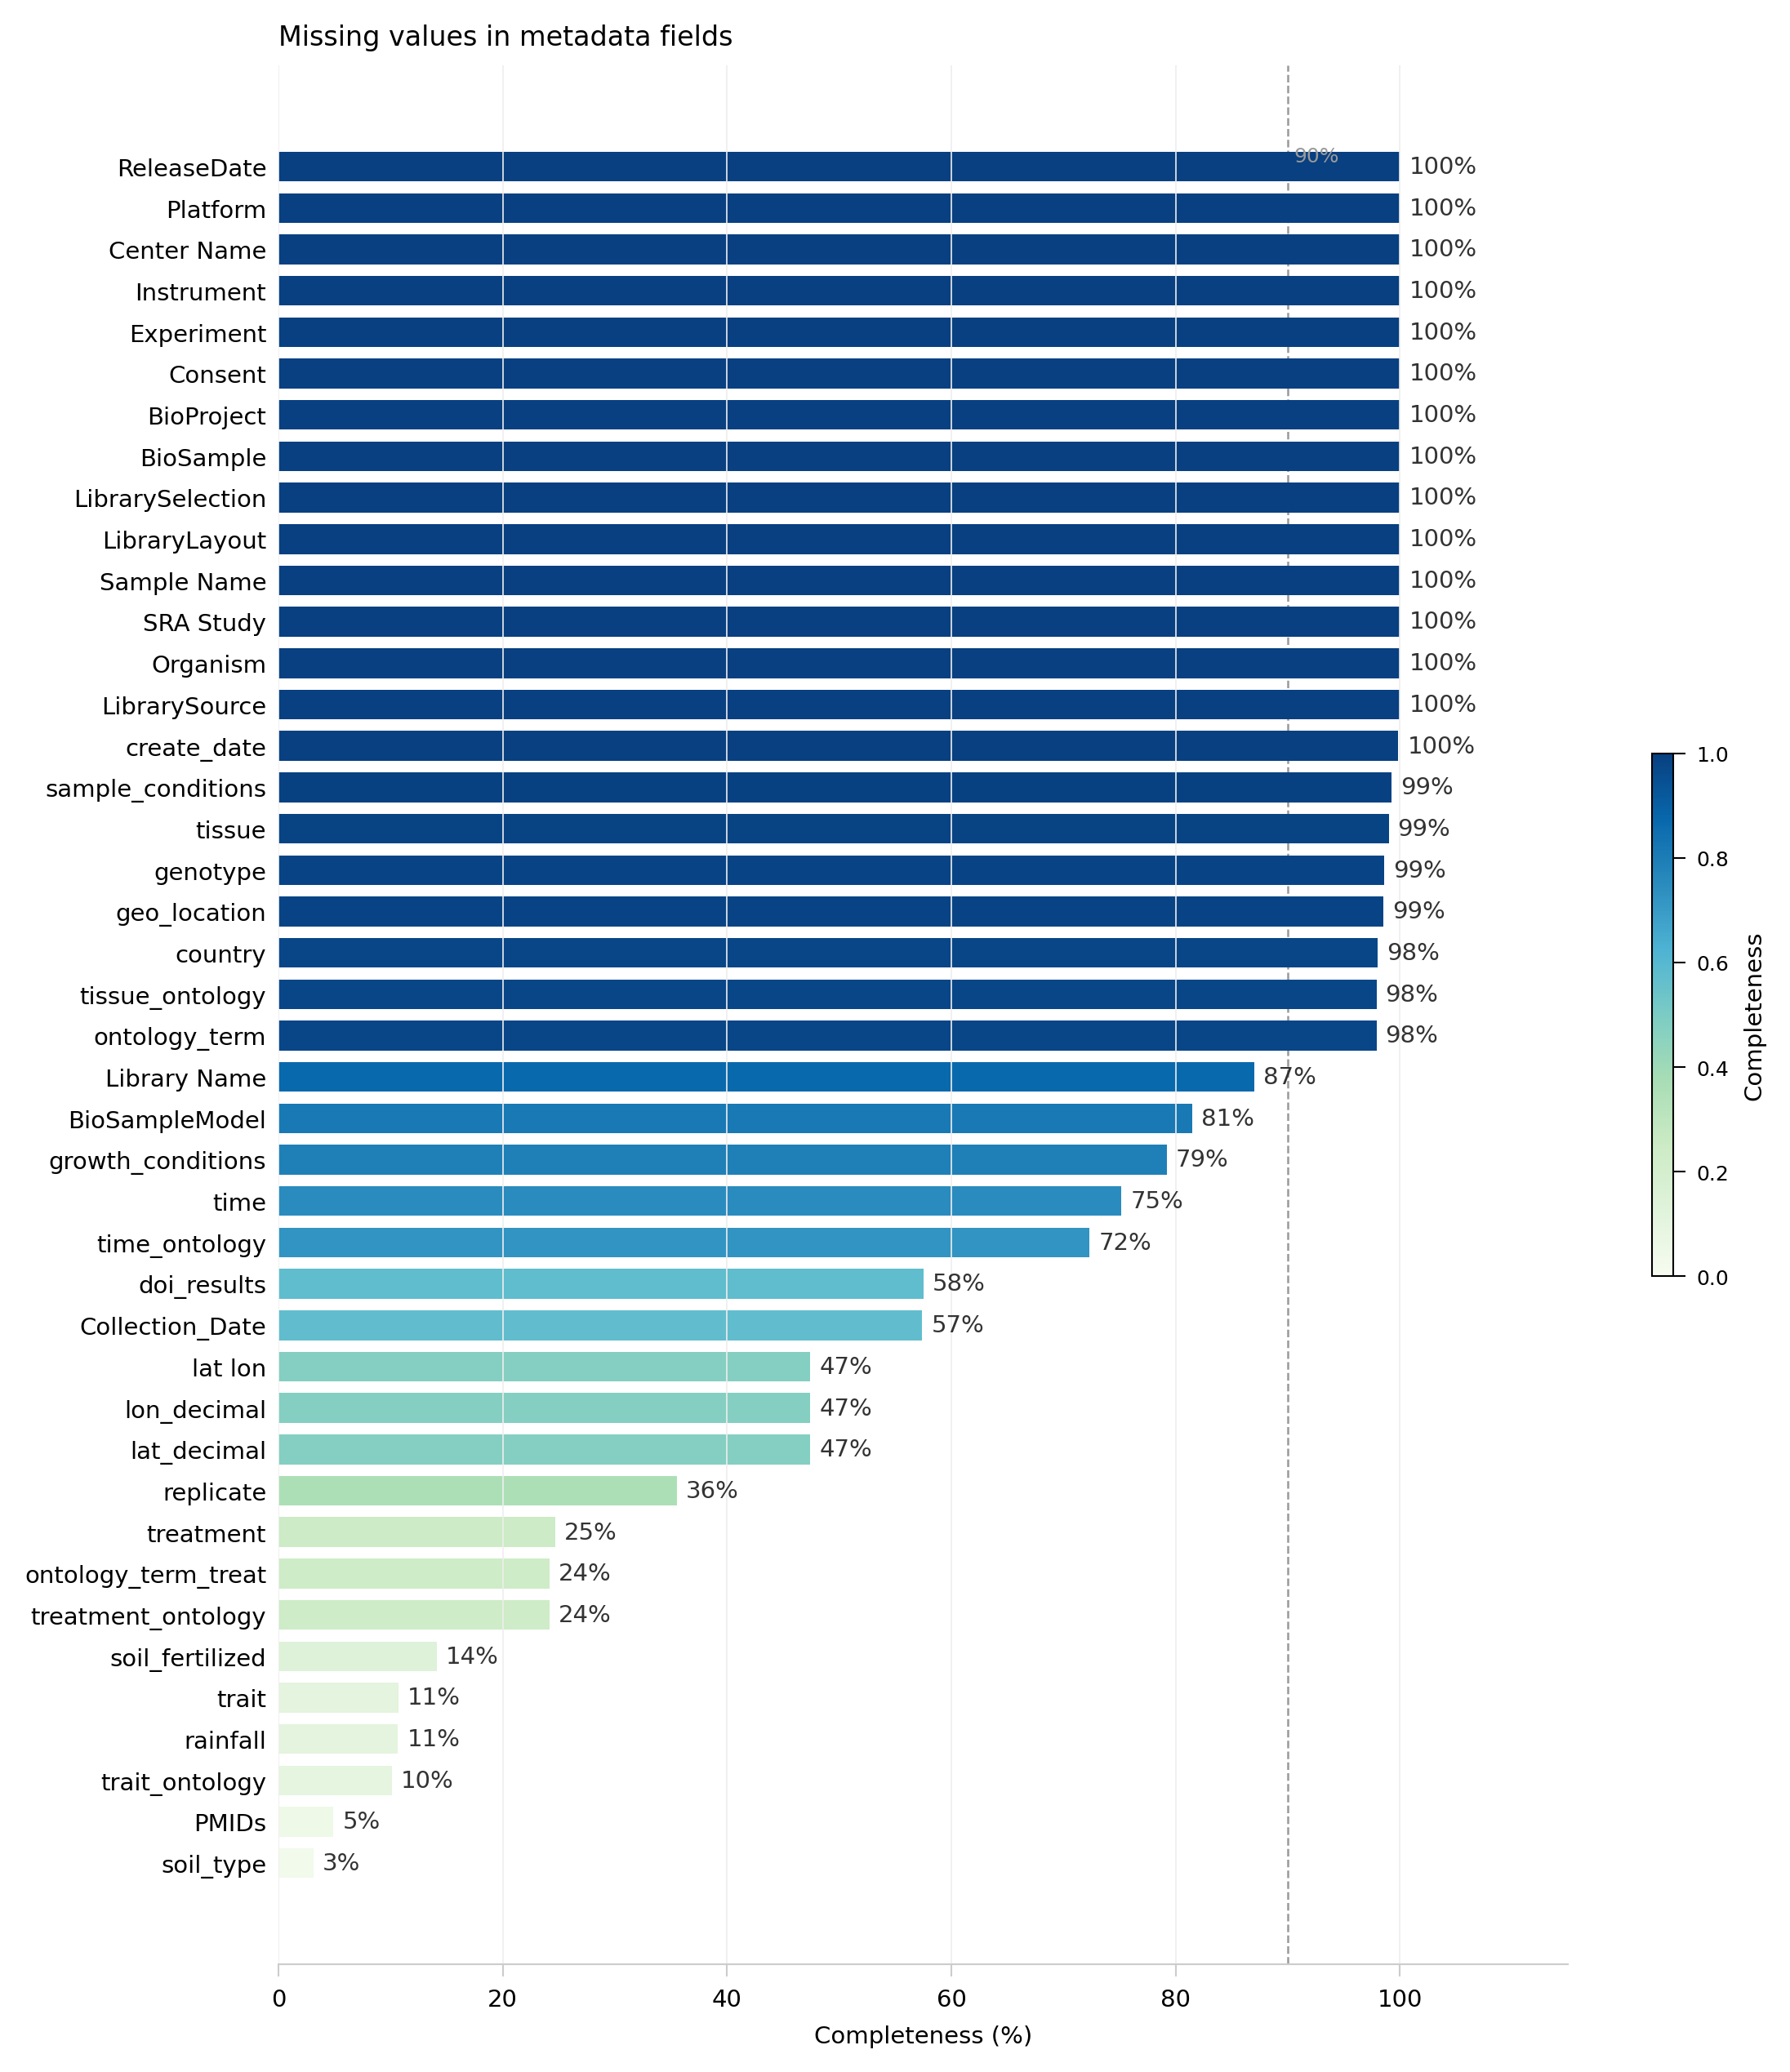

In [19]:
# Remove columns related about the data, e.g. Run, Assay Type, AvgSpotLen, Bases, Bytes, DATASTORE filetype, DATASTORE provider, DATASTORE region, version.
df_non_metadata = df.drop(
    columns=[
        "Run",
        "Assay Type",
        "AvgSpotLen",
        "Bases",
        "Bytes",
        "DATASTORE filetype",
        "DATASTORE provider",
        "DATASTORE region",
        "version",
        "RunCount",
    ]
)

columns = df_non_metadata.columns.tolist()

## Graph
## Completeness 
completeness = df_non_metadata.notna().mean().sort_values(ascending=True)
cmap = cm.get_cmap("GnBu") # colormap used in this article
norm = mcolors.Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in completeness.values]


# Figure size
MM_TO_IN = 1 / 25.4
FIG_WIDTH = 183 * MM_TO_IN                      # switch to 89 for single-column
FIG_HEIGHT = len(completeness) * 0.18 + 0.8     # scales with row count

# Parameters for Figure
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        7,
    "axes.titlesize":   8,
    "axes.labelsize":   7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "figure.dpi":       300,
})

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

bars = ax.barh(
    y=range(len(completeness)),
    width=completeness.values * 100,
    color=colors,
    height=0.72,
    edgecolor="none"
)

# Labels at the end of the bars
for i, val in enumerate(completeness.values):
    ax.text(
        val * 100 + 0.8, i,
        f"{val:.0%}",
        va="center", ha="left",
        fontsize=7, color="#333333",
        fontfamily="Arial"
    )

# Line at 90% completeness
ax.axvline(90, color="#999999", linewidth=0.6, linestyle="--", zorder=0)
ax.text(90.5, len(completeness) - 0.5, "90%",
        fontsize=6, color="#999999", va="top", fontfamily="Arial")

# Y-axis labels and limits
ax.set_yticks(range(len(completeness)))
ax.set_yticklabels(completeness.index, fontsize=7)
ax.set_xlim(0, 115)
ax.set_xlabel("Completeness (%)", fontsize=7, labelpad=4)

# Aesthetic adjustments for a clean, modern look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.spines["bottom"].set_linewidth(0.5)
ax.xaxis.set_tick_params(color="#cccccc", width=0.5)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color="#eeeeee", linewidth=0.4, zorder=0)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                    fraction=0.015, pad=0.06, aspect=25)
cbar.set_label("Completeness", fontsize=7, labelpad=4)
cbar.ax.tick_params(labelsize=6, width=0.5)
cbar.outline.set_linewidth(0.5)

# Title and layout
ax.set_title("Missing values in metadata fields",
             fontsize=8, fontweight="normal", pad=6, loc="left")

plt.tight_layout(pad=0.5)

# save the figure with a white background and without transparency to ensure it looks good in all contexts (e.g., printed, on different websites, etc.)
fig.savefig(
    "../figures/figure1_completeness.png",
    dpi=300,
    format="png",
    bbox_inches="tight",
    facecolor="white",
    transparent=False
)
plt.show()

/tmp/ipykernel_18705/2928775264.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("GnBu")


<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

...

[Text(0, 0, 'soil_type'),
 Text(0, 1, 'PMIDs'),
 Text(0, 2, 'trait_ontology'),
 Text(0, 3, 'rainfall'),
 Text(0, 4, 'trait'),
 Text(0, 5, 'soil_fertilized'),
 Text(0, 6, 'treatment_ontology'),
 Text(0, 7, 'ontology_term_treat'),
 Text(0, 8, 'treatment'),
 Text(0, 9, 'replicate'),
 Text(0, 10, 'lat_decimal'),
 Text(0, 11, 'lon_decimal'),
 Text(0, 12, 'lat lon'),
 Text(0, 13, 'Collection_Date'),
 Text(0, 14, 'doi_results'),
 Text(0, 15, 'time_ontology'),
 Text(0, 16, 'time'),
 Text(0, 17, 'growth_conditions'),
 Text(0, 18, 'BioSampleModel'),
 Text(0, 19, 'tissue_ontology'),
 Text(0, 20, 'ontology_term'),
 Text(0, 21, 'country'),
 Text(0, 22, 'geo_location'),
 Text(0, 23, 'genotype'),
 Text(0, 24, 'tissue'),
 Text(0, 25, 'sample_conditions')]

(0.0, 120.0)

Text(0.5, 0, 'Completeness (%)')

Text(0.0, 1.0, 'Completeness in metadata fields  —  Before vs After')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

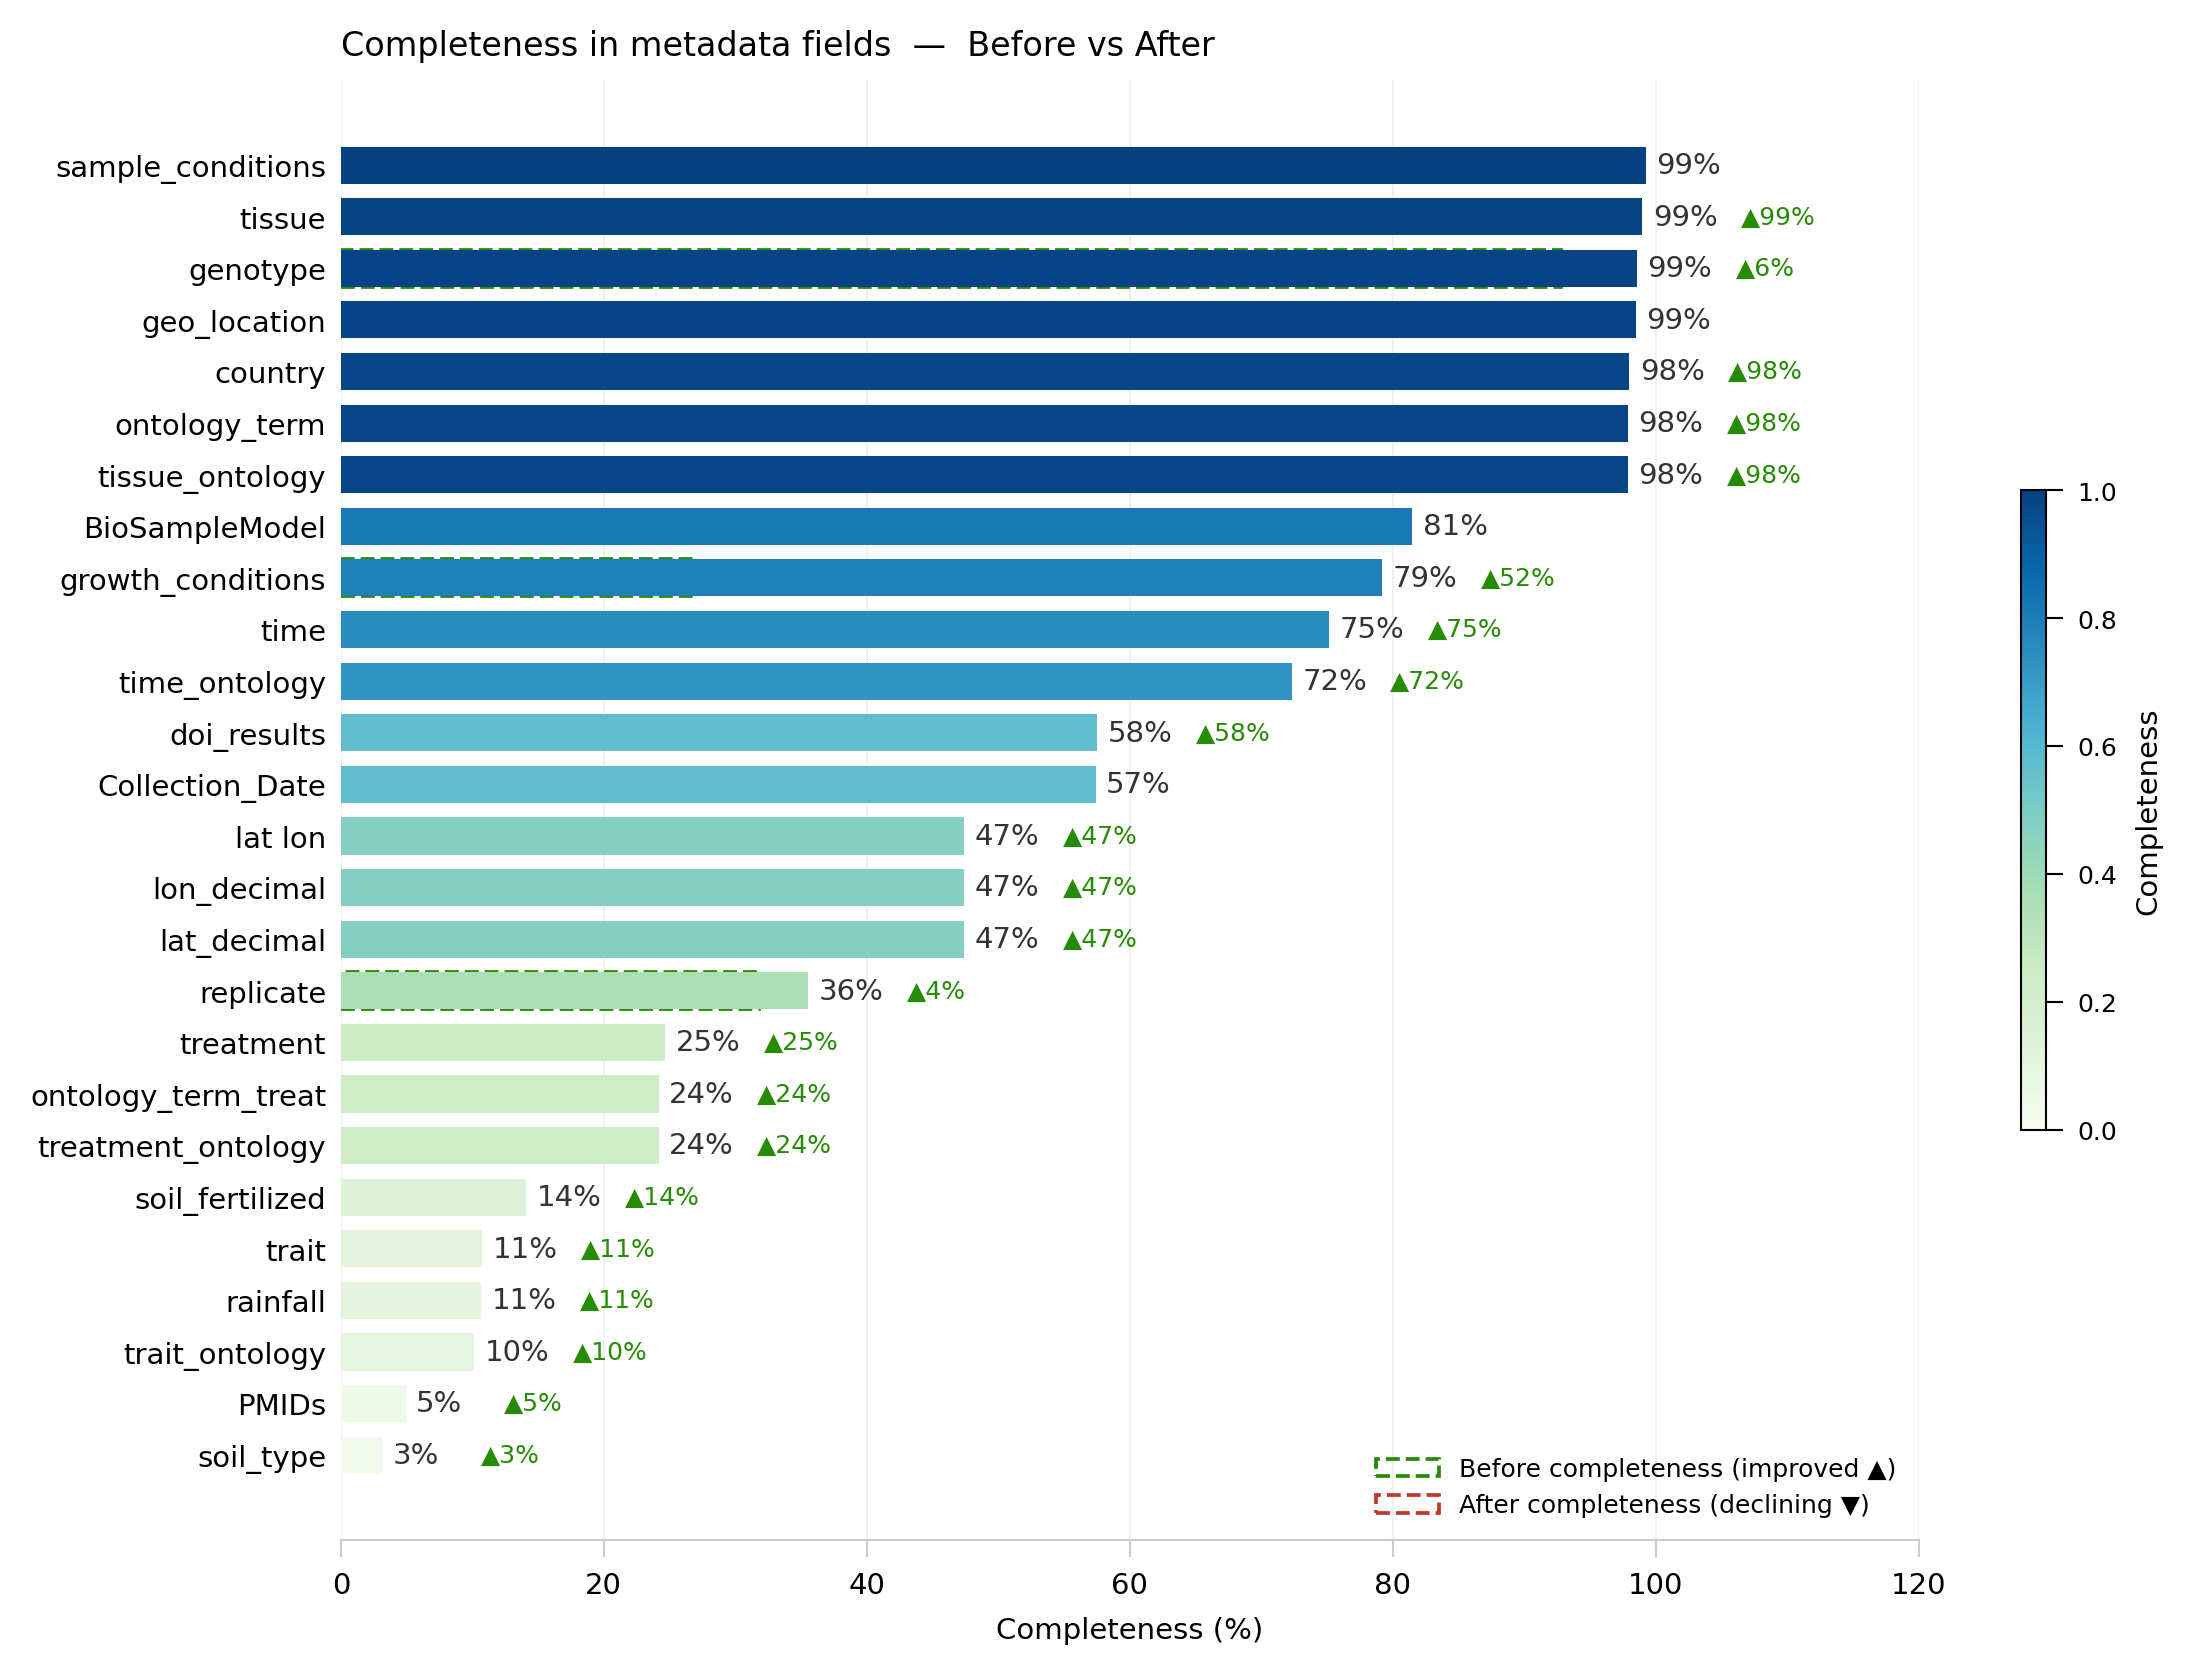

replicate antes: 0.318208778173191 depois: 0.3555753262158956 delta: 0.03736654804270462
growth_conditions antes: 0.27105575326215897 depois: 0.7921115065243179 delta: 0.5210557532621589
genotype antes: 0.928232502965599 depois: 0.9857651245551602 delta: 0.057532621589561184
[]
[]


In [24]:
# Drop metadata columns from BOTH dataframes 
drop_cols = [
    "Run",
    "Assay Type",
    "AvgSpotLen",
    "Bases",
    "Bytes",
    "DATASTORE filetype",
    "DATASTORE provider",
    "DATASTORE region",
    "version",
    "RunCount",
    "Center Name",
    "Instrument",
    "Consent",
    "BioProject",
    "BioSample",
    "LibrarySelection",
    "LibraryLayout",
    "Platform",
    "ReleaseDate",
    "Organism",
    "LibrarySource",
    "Sample Name",
    "SRA Study",
    "create_date",
    "Experiment",
    "Library Name",
]

df_non_metadata = df.drop(columns=drop_cols)
df_before_non_metadata = sugar_rna_df_before.drop(
    columns=[c for c in drop_cols if c in sugar_rna_df_before.columns]
)

columns = df_non_metadata.columns.tolist()

# Completeness: before = sugar_rna_df_before, after = df 
# New columns in df that didn't exist in sugar_rna_df_before get before=0
completeness_after  = df_non_metadata[columns].notna().mean()

completeness_before = pd.Series(index=columns, dtype=float)
for col in columns:
    if col in df_before_non_metadata.columns:
        completeness_before[col] = df_before_non_metadata[col].notna().mean()
    else:
        completeness_before[col] = 0.0   # column didn't exist before → 0% complete

delta = completeness_after - completeness_before   # + improved, - worsened

# Sort by after-completeness ascending (lowest at bottom)
order               = completeness_after.sort_values(ascending=True).index
completeness_after  = completeness_after[order]
completeness_before = completeness_before[order]
delta               = delta[order]

# Colormap
cmap   = cm.get_cmap("GnBu")
norm   = mcolors.Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in completeness_after.values]

# Figure parameters
MM_TO_IN   = 1 / 25.4
FIG_WIDTH  = 183 * MM_TO_IN
FIG_HEIGHT = len(completeness_after) * 0.18 + 0.8

plt.rcParams.update({
    "font.family":     "Arial",
    "font.size":       7,
    "axes.titlesize":  8,
    "axes.labelsize":  7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.dpi":      300,
})

plt.close("all")   # close any previous figures to avoid overlap or memory issues

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
y = np.arange(len(completeness_after))

# Ghost bars: sugar_rna_df_before completeness
THRESH = 0.01
for i, (v_before, d) in enumerate(zip(completeness_before.values, delta.values)):
    if abs(d) < THRESH:
        continue
    #edge_color = "#d4622a" if d >= 0 else "#c0392b"   # orange=improved, red=worsened
    edge_color = "#268b05" if d >= 0 else "#c0392b"   # green=improved, red=worsened
    ax.barh(
        y=i,
        width=v_before * 100,
        color="none",
        edgecolor=edge_color,
        linewidth=0.9,
        height=0.72,
        linestyle="--",
        zorder=2,
    )

# Main bars: df completeness (after) 
ax.barh(
    y=y,
    width=completeness_after.values * 100,
    color=colors,
    height=0.72,
    edgecolor="none",
    zorder=3,
)

# Percentage labels + delta annotation 
for i, (val, d) in enumerate(zip(completeness_after.values, delta.values)):
    ax.text(
        val * 100 + 0.8, i,
        f"{val:.0%}",
        va="center", ha="left",
        fontsize=7, color="#333333", fontfamily="Arial",
    )
    if abs(d) >= THRESH:
        sign        = "▲" if d >= 0 else "▼"
        delta_color = "#268b05" if d >= 0 else "#c0392b"
        ax.text(
            val * 100 + 7.5, i,
            f"{sign}{abs(d):.0%}",
            va="center", ha="left",
            fontsize=6, color=delta_color, fontfamily="Arial",
        )

# 90 % reference line 
# ax.axvline(90, color="#999999", linewidth=0.6, linestyle="--", zorder=0)
# ax.text(90.5, len(completeness_after) - 0.5, "90%",
#         fontsize=6, color="#999999", va="top", fontfamily="Arial")

# Axes styling
ax.set_yticks(y)
ax.set_yticklabels(completeness_after.index, fontsize=7)
ax.set_xlim(0, 120)
ax.set_xlabel("Completeness (%)", fontsize=7, labelpad=4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.spines["bottom"].set_linewidth(0.5)
ax.xaxis.set_tick_params(color="#cccccc", width=0.5)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color="#eeeeee", linewidth=0.4, zorder=0)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                    fraction=0.015, pad=0.06, aspect=25)
cbar.set_label("Completeness", fontsize=7, labelpad=4)
cbar.ax.tick_params(labelsize=6, width=0.5)
cbar.outline.set_linewidth(0.5)

# Legend 
improved_patch = mpatches.Patch(
    facecolor="none", edgecolor="#268b05", linewidth=0.9, linestyle="--",
    label="Before completeness (improved ▲)"
)
worsened_patch = mpatches.Patch(
    facecolor="none", edgecolor="#c0392b", linewidth=0.9, linestyle="--",
    label="After completeness (declining ▼)"
)
ax.legend(
    handles=[improved_patch, worsened_patch],
    fontsize=6, frameon=False,
    loc="lower right", bbox_to_anchor=(1.0, 0.0),
    handlelength=2.5,
)

# Title & save
ax.set_title(
    "Completeness in metadata fields  —  Before vs After",
    fontsize=8, fontweight="normal", pad=6, loc="left"
)

plt.tight_layout(pad=0.5)

fig.savefig(
    "../figures/figure_completeness.png",
    dpi=300, format="png",
    bbox_inches="tight",
    facecolor="white", transparent=False,
)
plt.show()

for col in ["replicate", "growth_conditions", "genotype"]:
    print(col, "antes:", completeness_before[col], "depois:", completeness_after[col], "delta:", delta[col])
    
print(df.columns[df.columns.duplicated()].tolist())
print(sugar_rna_df_before.columns[sugar_rna_df_before.columns.duplicated()].tolist())    

# Stack Plot

In [21]:
# Rename columns in sugar_rna_df_before to match those in df for easier comparison
rename_mapping = {
    'geo_loc_name': 'geo_location',
    'isolation_and_growth_condition': 'growth_conditions',
    'AGE': 'time',
    'lat_lon': 'lat lon',
    'geo_loc_name_country': 'country',
}
sugarcane_rna_df.rename(columns=rename_mapping, inplace=True)

# select only these columns below
columns_to_compare = [
    'tissue',
    'genotype',
    'geo_location',
    'growth_conditions',
    'time',
    'lat lon',
    'replicate',
    'treatment',
    'country',
]

# select only the columns to compare from both dataframes
df_before_comp = sugarcane_rna_df[columns_to_compare].copy()
df_after_comp = df[columns_to_compare].copy()

/tmp/ipykernel_18705/290641393.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("GnBu")


<BarContainer object of 9 artists>

<BarContainer object of 9 artists>

Text(0, 1.0049169632265718, '99%')

Text(0, 0.4098457888493476, '82%')

...

[Text(0, 0, 'Tissue (n=3338)'),
 Text(1, 0, 'Genotype (n=3324)'),
 Text(2, 0, 'Geo Location (n=3322)'),
 Text(3, 0, 'Growth Conditions (n=2671)'),
 Text(4, 0, 'Time (n=2535)'),
 Text(5, 0, 'Lat / Lon (n=1599)'),
 Text(6, 0, 'Replicate (n=1199)'),
 Text(7, 0, 'Treatment (n=832)'),
 Text(8, 0, 'Country (n=3305)')]

Text(0, 0.5, 'Completeness (proportion)')

Text(0.5, 0, 'Metadata field')

Text(0.5, 1.0, 'Metadata Completeness Before and After Curation')

(0.0, 1.12)

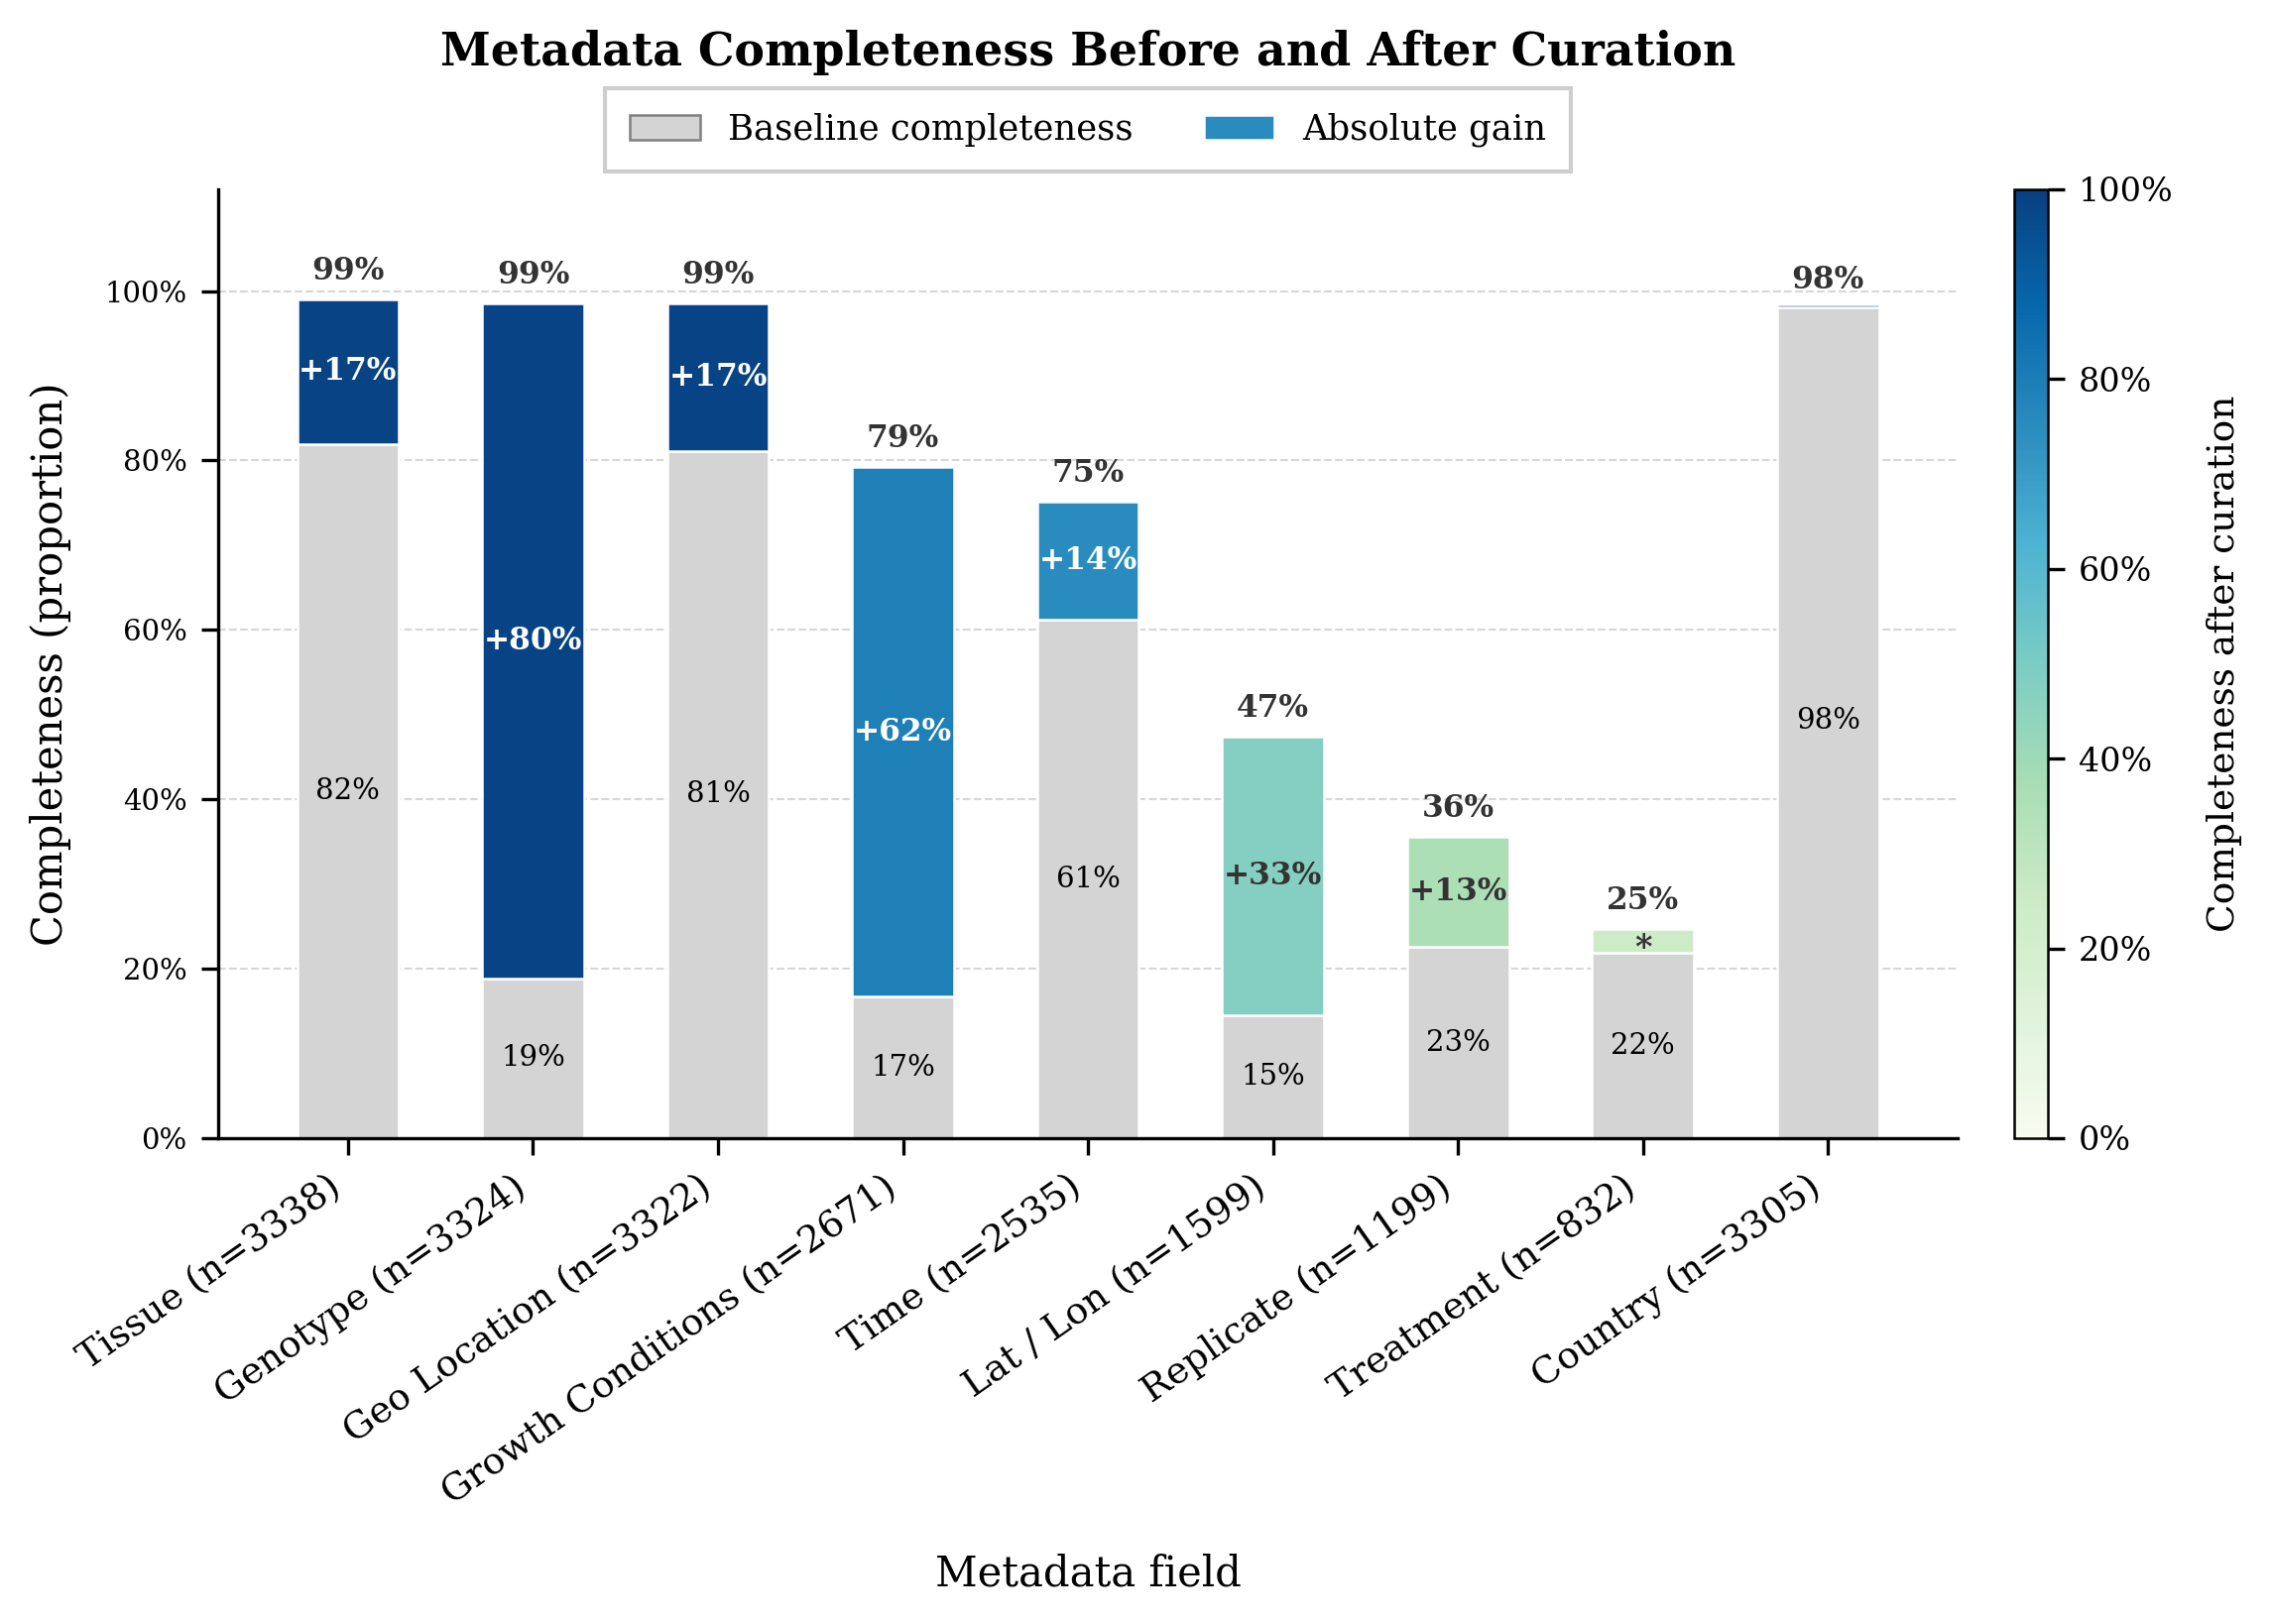

In [39]:
# Completeness calculation 
completeness_before = df_before_comp.notna().mean()
completeness_after  = df_after_comp.notna().mean()
gain                = completeness_after - completeness_before

# Count the number of non-missing values for each column in both dataframes
record_counts = df_after_comp.notna().sum().to_dict()

# Colormap setup
cmap   = cm.get_cmap("GnBu")
norm   = mcolors.Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in completeness_after.values]

# Formatted x-axis labels
label_mapping = {
    'tissue':            'Tissue',
    'genotype':          'Genotype',
    'geo_location':      'Geo Location',
    'growth_conditions': 'Growth Conditions',
    'time':              'Time',
    'lat lon':           'Lat / Lon',
    'replicate':         'Replicate',
    'treatment':         'Treatment',
    'country':           'Country',
}
# labels = [label_mapping.get(col, col) for col in completeness_before.index]
labels = [f"{label_mapping.get(col, col)} (n={record_counts[col]})" for col in completeness_before.index]

# Parameters for the figure
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})

# Figure — extra top margin to host the legend above the axes
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
fig.subplots_adjust(right=0.82, bottom=0.25, top=0.83)  # bottom for rotated labels, top for legend

x = np.arange(len(completeness_before))
width = 0.55

# Bottom bars — BEFORE
ax.bar(
    x, completeness_before.values,
    width=width, color="#d4d4d4",
    edgecolor="white", linewidth=0.6, zorder=2,
)

# Top bars — GAIN
ax.bar(
    x, gain.values,
    width=width, bottom=completeness_before.values,
    color=colors, edgecolor="white", linewidth=0.6, zorder=2,
)

# Annotations on top of each bar
for i, (b, a, g) in enumerate(zip(completeness_before.values, completeness_after.values, gain.values)):
    # Final completeness
    ax.text(
        x[i], a + 0.015, f"{a:.0%}",
        ha='center', va='bottom',
        fontsize=7.5, color='#333333', fontfamily='serif', fontweight='bold'
    )
    
    # Baseline completeness
    if b > 0.04: # Only show if the baseline is greater than 4% to avoid cluttering the plot with very small values
        ax.text(
            x[i], b / 2, f"{b:.0%}",
            ha='center', va='center',
            fontsize=7, color="#000000", fontfamily='serif'
        )
        
    # Absolute percentage-point gain 
    if g > 0.04: # Only show if the gain is greater than 4% to avoid cluttering the plot with very small values
        text_color = "white" if a >= 0.6 else "#333333"
        
        ax.text(
            x[i], b + (g / 2), f"+{g:.0%}",
            ha='center', va='center',
            fontsize=7.5, 
            color=text_color, 
            fontfamily='serif',
            fontweight='bold' # Helps the gain annotation stand out against the bar colors, especially for darker shades of blue
        )
    
    elif 0 < g <= 0.04:
        # For very small gains, we can use an asterisk to indicate that there was a gain, but it's too small to display as a percentage.
        text_color = "white" if a >= 0.6 else "#333333"
        
        ax.text(
            x[i], b + (g / 2) - 0.008, "*", # O -0.008 helps position the asterisk slightly below the center of the gain area for better visibility
            ha='center', va='center',
            fontsize=8,  # Slightly larger font size for the asterisk to make it more noticeable
            color=text_color, 
            fontfamily='serif',
            fontweight='bold'
        )

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03, aspect=28)
cbar.set_label("Completeness after curation", fontsize=9, labelpad=8)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
cbar.outline.set_linewidth(0.6)
cbar.ax.tick_params(labelsize=8)

# Legend — placed ABOVE the axes, outside the plot area
before_patch = mpatches.Patch(facecolor="#d4d4d4", edgecolor="grey",
                               linewidth=0.6, label="Baseline completeness")
gain_patch   = mpatches.Patch(facecolor=cmap(norm(0.75)), edgecolor="white",
                               linewidth=0.6, label="Absolute gain")
ax.legend(
    handles=[before_patch, gain_patch],
    loc='lower center',             # place the legend at the bottom center of the figure
    bbox_to_anchor=(0.5, 1),        # X=0.5 middle of the figure, Y=1 means just above the top edge of the axes
    ncol=2,                        
    fontsize=8.5,
    frameon=True,
    framealpha=0.95,
    edgecolor='#cccccc',
    fancybox=False,
    borderpad=0.7,
)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)  # rotated 35°
ax.set_ylabel("Completeness (proportion)", fontsize=10, labelpad=8)
ax.set_xlabel("Metadata field", fontsize=10, labelpad=10)
ax.set_title(
    "Metadata Completeness Before and After Curation",
    fontsize=11, fontweight='bold', pad=30,   # extra pad so title clears the legend
)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# plt.savefig("completeness_plot.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../figures/completeness_plot.png", bbox_inches='tight', dpi=300)
plt.show()